In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')
import re 

# Custom font (optional)
font_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

## Functions

In [2]:
_DEFAULT_INTENSITIES = ["Eighth", "Quarter", "Half", "Full"]
_DEFAULT_INTENSITY_COLORS = {'Eighth': '#c7e9c0', 'Quarter': '#74c476', 'Half': '#31a354', 'Full': '#006d2c'}
_DEFAULT_METRICS = [
    "PI_Hg_OSAR", "Log2 Speed ratio_Hg_OSAR", "Log2 Bout Speed ratio_Hg_OSAR",
    "Light Attraction Index_Hg_OSAR", "Bout Number Index_Hg_OSAR", "Bout Duration ratio_Hg_OSAR",
    "Max Velocity ratio_Hg_OSAR", "Speed ratio_Hg_OSAR", "Bout Speed ratio_Hg_OSAR"
]
_DEFAULT_METRIC_DISPLAY = {
    "PI_Hg_OSAR": "PI", "Log2 Speed ratio_Hg_OSAR": "Log2 Speed Ratio",
    "Log2 Bout Speed ratio_Hg_OSAR": "Log2 Bout Speed Ratio", "Light Attraction Index_Hg_OSAR": "Light Attraction Index",
    "Bout Number Index_Hg_OSAR": "Bout Number Index", "Bout Duration ratio_Hg_OSAR": "Bout Duration Ratio",
    "Max Velocity ratio_Hg_OSAR": "Max Velocity Ratio", "Speed ratio_Hg_OSAR": "Speed Ratio",
    "Bout Speed ratio_Hg_OSAR": "Bout Speed Ratio"
}

 
def load_bootstrap_data(data_path, responders=None, intensities=None, metrics=None):
    intensities = intensities or _DEFAULT_INTENSITIES
    metrics = metrics or _DEFAULT_METRICS
    all_data = {}
    
    for filename in [f for f in os.listdir(data_path) if f.endswith('_bootstrap.csv')]:
        parts = filename.replace('_bootstrap.csv', '').split(' x ')
        if len(parts) != 2: continue
        mbon, responder = parts
        if responders and responder not in responders: continue
        if responder not in all_data:
            all_data[responder] = {i: {m: {} for m in metrics} for i in intensities}
        
        try:
            df = pd.read_csv(os.path.join(data_path, filename))
            for (intensity, metric), group in df.groupby(['Light_Intensity', 'Metric']):
                if intensity in intensities and metric in metrics:
                    all_data[responder][intensity][metric][mbon] = {
                        'bootstrap': group['Bootstrap'].values,
                        'effect': group['Hedges_g'].iloc[0],
                        'ci_low': group['CI_low'].iloc[0],
                        'ci_high': group['CI_high'].iloc[0]
                    }
        except Exception as e:
            print(f"Error reading {filename}: {e}")
    return all_data

def get_effect(data, responder, intensity, metric, mbon):
    try:
        d = data[responder][intensity][metric][mbon]
        return d['effect'], d['ci_low'], d['ci_high']
    except KeyError:
        return None, None, None

def get_bootstrap(data, responder, intensity, metric, mbon):
    try:
        return data[responder][intensity][metric][mbon]['bootstrap']
    except KeyError:
        return np.zeros(5000)

def get_sorted_mbons(data, responder, metric, sort_by='Full'):
    mbons = set()
    for intensity in data[responder]:
        mbons.update(data[responder][intensity][metric].keys())
    return [m for m, _ in sorted([(m, get_effect(data, responder, sort_by, metric, m)[0] or 0) for m in mbons], key=lambda x: x[1])]

def get_mbons_by_number(data, responder, lobelocation):
    mbons = set()
    for intensity in data[responder]:
        for metric in data[responder][intensity]:
            mbons.update(data[responder][intensity][metric].keys())
    
    if lobelocation is None or lobelocation.empty:
        return sorted(list(mbons))
    
    def sort_key(mbon):
        info = lobelocation[lobelocation['MBON'] == mbon]
        if len(info) > 0:
            match = re.search(r'(\d+)', str(info['MBON_number'].values[0]).strip())
            if match: return int(match.group(1))
        return 999
    return sorted(list(mbons), key=sort_key)

def get_available_metrics(metrics=None):
    return metrics or _DEFAULT_METRICS

def _create_labels(mbons, lobelocation, sep='\n'):
    if lobelocation is None or lobelocation.empty: return list(mbons)
    labels = []
    for mbon in mbons:
        info = lobelocation[lobelocation['MBON'] == mbon]
        if len(info) > 0:
            parts = [str(info['MBON_number'].values[0]), str(info['Lobe_location'].values[0]), mbon]
            labels.append(sep.join([p for p in parts if p and p != 'nan']) or mbon)
        else:
            labels.append(mbon)
    return labels

def find_number(df, lookup, col):
    vals = []
    for _, row in df.iterrows():
        if lookup in [x.strip() for x in row['MBON names'].split(',')]:
            vals.append(row[col])
    return ', '.join(list(set(vals)))

def _get_text_color_from_center(spirals, row_idx, col_idx, n, cmap, vmin, vmax):
    cy, cx = row_idx * n + n // 2, col_idx * n + n // 2
    center_val = np.mean(spirals[cy-1:cy+2, cx-1:cx+2])
    norm_val = np.clip((center_val - vmin) / (vmax - vmin), 0, 1) if vmax != vmin else 0.5
    cmap_obj = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    rgba = cmap_obj(norm_val)
    luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
    return 'white' if luminance < 0.5 else 'black'

def _sample_bootstrap(bootstrap, m, n, chop_tail=2.5):
    bs = sorted(bootstrap)
    chop = int(np.ceil(len(bs) * chop_tail / 100))
    bs = bs[chop:len(bs)-chop]
    ranks = np.linspace(0, len(bs), m*n, dtype=int)
    ranks[0] = 1
    if np.sum(np.array(bs) > 0) < len(bs)/2: bs = bs[::-1]
    return [bs[r-1] for r in ranks]

def _spiralize(fill, m, n):
    i, j, k = 0, 0, 0
    arr = np.zeros((m, n))
    while m > 0 and k < len(fill):
        jj, ii = j, i
        for j in range(j, n):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        for i in range(ii+1, m):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        for j in range(n-2, jj-1, -1):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        for i in range(m-2, ii, -1):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        m -= 1; n -= 1; j += 1
    return arr

def create_vortexmap(data, responder, metric, intensities=None, lobelocation=None,
                     cmap='coolwarm', figsize=None, chop_tail=2.5,
                     vmin=None, vmax=None,
                     annot=True, annot_fontsize=9, annot_fmt='.2f',
                     title=None, title_fontsize=14, title_fontweight='bold',
                     xlabel=None, xlabel_fontsize=12,
                     xticklabels=None, xticklabels_fontsize=10, xticklabels_rotation=0,
                     ylabel=None, ylabel_fontsize=12,
                     yticklabels=None, yticklabels_fontsize=10, yticklabels_rotation=0,
                     yticklabels_sep=' --- ',
                     cbar=True, cbar_label="Hedge's g", cbar_orientation='horizontal',
                     cbar_ticks=[-1, 0, 1],
                     cbar_x=None, cbar_y=None, cbar_width=0.3, cbar_height=0.02,
                     cbar_labelsize=10, cbar_ticksize=8):
    
    intensities = intensities or _DEFAULT_INTENSITIES
    mbons = get_mbons_by_number(data, responder, lobelocation)
    n = 9 if len(mbons) > 30 else (11 if len(mbons) > 15 else 15)
    n_rows, n_cols = len(mbons), len(intensities)
    vmin = vmin if vmin is not None else cbar_ticks[0]
    vmax = vmax if vmax is not None else cbar_ticks[-1]
    
    spirals = np.zeros((n_rows*n, n_cols*n))
    mean_vals = np.zeros((n_rows, n_cols))
    for i, mbon in enumerate(mbons):
        for j, intensity in enumerate(intensities):
            samples = _sample_bootstrap(get_bootstrap(data, responder, intensity, metric, mbon), n, n, chop_tail)
            spirals[i*n:(i+1)*n, j*n:(j+1)*n] = _spiralize(samples, n, n)
            mean_vals[i, j] = np.mean(samples)
    
    fig, ax = plt.subplots(figsize=figsize or (n_cols*2.5, n_rows*0.6))
    sns.heatmap(spirals, cmap=cmap, vmin=vmin, vmax=vmax, center=0, cbar=False, ax=ax)
    
    ax.set_xticks(np.linspace(n/2, n_cols*n-n/2, n_cols))
    ax.set_xticklabels(xticklabels or intensities, rotation=xticklabels_rotation, ha='center', fontsize=xticklabels_fontsize)
    if xlabel: ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    
    ax.set_yticks(np.linspace(n/2, n_rows*n-n/2, n_rows))
    ax.set_yticklabels(yticklabels or _create_labels(mbons, lobelocation, sep=yticklabels_sep), 
                       rotation=yticklabels_rotation, fontsize=yticklabels_fontsize)
    if ylabel: ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
    if title: ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight)
    
    if annot:
        for i in range(n_rows):
            for j in range(n_cols):
                ax.text(j*n+n/2, i*n+n/2, f'{mean_vals[i,j]:{annot_fmt}}', ha='center', va='center',
                       fontsize=annot_fontsize, color=_get_text_color_from_center(spirals, i, j, n, cmap, vmin, vmax))
    
    if cbar:
        cax = fig.add_axes([cbar_x or 0.25, cbar_y or 0.02, cbar_width, cbar_height])
        cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), 
                         cax=cax, orientation=cbar_orientation)
        cb.set_ticks(cbar_ticks)
        cb.set_label(cbar_label, fontsize=cbar_labelsize)
        cb.ax.tick_params(labelsize=cbar_ticksize)
    
    plt.tight_layout()
    return fig, ax, mbons, mean_vals

def create_multi_vortexmap(data, responder, metrics, intensities=None, lobelocation=None,
                           cmap='coolwarm', figsize=None, chop_tail=2.5,
                           vmin=None, vmax=None,
                           annot=True, annot_fontsize=8, annot_fmt='.2f',
                           title=None, title_fontsize=16, title_fontweight='bold', title_y=0.99,
                           subplot_titles=None, subplot_title_fontsize=14, subplot_title_fontweight='bold',
                           xlabel=None, xlabel_fontsize=12,
                           xticklabels=None, xticklabels_fontsize=10, xticklabels_rotation=0,
                           ylabel=None, ylabel_fontsize=12,
                           yticklabels=None, yticklabels_fontsize=10, yticklabels_rotation=0,
                           yticklabels_sep=' --- ',
                           cbar=True, cbar_label="Hedge's g", cbar_orientation='horizontal',
                           cbar_ticks=[-1, 0, 1],
                           cbar_x=None, cbar_y=None, cbar_width=0.3, cbar_height=0.015,
                           cbar_labelsize=10, cbar_ticksize=8,
                           layout_rect=None, metric_display=None):
    
    intensities = intensities or _DEFAULT_INTENSITIES
    metric_display = metric_display or _DEFAULT_METRIC_DISPLAY
    mbons = get_mbons_by_number(data, responder, lobelocation)
    n = 9 if len(mbons) > 30 else (11 if len(mbons) > 15 else 15)
    n_rows, n_cols, n_metrics = len(mbons), len(intensities), len(metrics)
    vmin = vmin if vmin is not None else cbar_ticks[0]
    vmax = vmax if vmax is not None else cbar_ticks[-1]
    
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize or (5*n_metrics, n_rows*0.6))
    if n_metrics == 1: axes = [axes]
    subplot_titles = subplot_titles or [metric_display.get(m, m) for m in metrics]
    ytick_labels = yticklabels or _create_labels(mbons, lobelocation, sep=yticklabels_sep)
    all_mean_vals = []
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        spirals = np.zeros((n_rows*n, n_cols*n))
        mean_vals = np.zeros((n_rows, n_cols))
        
        for i, mbon in enumerate(mbons):
            for j, intensity in enumerate(intensities):
                samples = _sample_bootstrap(get_bootstrap(data, responder, intensity, metric, mbon), n, n, chop_tail)
                spirals[i*n:(i+1)*n, j*n:(j+1)*n] = _spiralize(samples, n, n)
                mean_vals[i, j] = np.mean(samples)
        all_mean_vals.append(mean_vals)
        
        sns.heatmap(spirals, cmap=cmap, vmin=vmin, vmax=vmax, center=0, cbar=False, ax=ax)
        ax.set_title(subplot_titles[idx], fontsize=subplot_title_fontsize, fontweight=subplot_title_fontweight)
        ax.set_xticks(np.linspace(n/2, n_cols*n-n/2, n_cols))
        ax.set_xticklabels(xticklabels or intensities, rotation=xticklabels_rotation, ha='center', fontsize=xticklabels_fontsize)
        if xlabel and idx == n_metrics // 2: ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
        ax.set_yticks(np.linspace(n/2, n_rows*n-n/2, n_rows))
        ax.set_yticklabels(ytick_labels, rotation=yticklabels_rotation, fontsize=yticklabels_fontsize)
        if idx == 0 and ylabel: ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
        if idx != 0: ax.tick_params(labelleft=False)
        
        if annot:
            for i in range(n_rows):
                for j in range(n_cols):
                    ax.text(j*n+n/2, i*n+n/2, f'{mean_vals[i,j]:{annot_fmt}}', ha='center', va='center',
                           fontsize=annot_fontsize, color=_get_text_color_from_center(spirals, i, j, n, cmap, vmin, vmax))
    
    if title: fig.suptitle(title, fontsize=title_fontsize, fontweight=title_fontweight, y=title_y)
    if cbar:
        cax = fig.add_axes([cbar_x or 0.35, cbar_y or 0.02, cbar_width, cbar_height])
        cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)),
                         cax=cax, orientation=cbar_orientation)
        cb.set_ticks(cbar_ticks)
        cb.set_label(cbar_label, fontsize=cbar_labelsize)
        cb.ax.tick_params(labelsize=cbar_ticksize)
    
    plt.tight_layout(rect=layout_rect or [0, 0.05, 1, 0.96])
    return fig, axes, mbons, all_mean_vals

def create_heatmap(data, responder, metric, intensities=None, lobelocation=None, 
                   cmap='coolwarm', vmin=-1.5, vmax=1.5, figsize=None,
                   annot=True, annot_fontsize=10, annot_fmt='.2f',
                   title=None, title_fontsize=14, title_fontweight='bold',
                   xlabel=None, xlabel_fontsize=12,
                   xticklabels=None, xticklabels_fontsize=10, xticklabels_rotation=0,
                   ylabel=None, ylabel_fontsize=12,
                   yticklabels_fontsize=10, yticklabels_rotation=0,
                   yticklabels_sep=' --- ',
                   cbar=True, cbar_label="Hedge's g"):
    
    intensities = intensities or _DEFAULT_INTENSITIES
    mbons = get_sorted_mbons(data, responder, metric)
    matrix = [[get_effect(data, responder, i, metric, m)[0] or np.nan for i in intensities] for m in mbons]
    df = pd.DataFrame(matrix, index=_create_labels(mbons, lobelocation, sep=yticklabels_sep),
                      columns=xticklabels or intensities)
    
    fig, ax = plt.subplots(figsize=figsize or (8, len(mbons)*0.4))
    sns.heatmap(df, cmap=cmap, center=0, vmin=vmin, vmax=vmax,
                annot=annot, fmt=annot_fmt, annot_kws={'fontsize': annot_fontsize},
                cbar=cbar, cbar_kws={'label': cbar_label} if cbar else None, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=xticklabels_fontsize, rotation=xticklabels_rotation)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=yticklabels_fontsize, rotation=yticklabels_rotation)
    if xlabel: ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    if ylabel: ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
    if title: ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight)
    plt.tight_layout()
    return fig, ax, df

def create_multi_heatmap(data, responder, metrics, intensities=None, lobelocation=None,
                         cmap='coolwarm', figsize=None, vmin=None, vmax=None,
                         annot=True, annot_fontsize=9, annot_fmt='.2f',
                         title=None, title_fontsize=16, title_fontweight='bold', title_y=0.99,
                         subplot_titles=None, subplot_title_fontsize=14, subplot_title_fontweight='bold',
                         xlabel=None, xlabel_fontsize=12,
                         xticklabels=None, xticklabels_fontsize=10, xticklabels_rotation=0,
                         ylabel=None, ylabel_fontsize=12,
                         yticklabels_fontsize=10, yticklabels_rotation=0,
                         yticklabels_sep=' --- ',
                         cbar=True, cbar_label="Hedge's g", cbar_orientation='horizontal',
                         cbar_ticks=[-1, 0, 1],
                         cbar_x=None, cbar_y=None, cbar_width=0.3, cbar_height=0.015,
                         cbar_labelsize=10, cbar_ticksize=8,
                         layout_rect=None, metric_display=None):
    
    intensities = intensities or _DEFAULT_INTENSITIES
    metric_display = metric_display or _DEFAULT_METRIC_DISPLAY
    mbons = get_mbons_by_number(data, responder, lobelocation)
    labels = _create_labels(mbons, lobelocation, sep=yticklabels_sep)
    n_metrics = len(metrics)
    vmin = vmin if vmin is not None else cbar_ticks[0]
    vmax = vmax if vmax is not None else cbar_ticks[-1]
    
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize or (4*n_metrics, len(mbons)*0.4))
    if n_metrics == 1: axes = [axes]
    subplot_titles = subplot_titles or [metric_display.get(m, m) for m in metrics]
    all_dfs = []
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        matrix = [[get_effect(data, responder, i, metric, m)[0] or np.nan for i in intensities] for m in mbons]
        df = pd.DataFrame(matrix, index=labels, columns=xticklabels or intensities)
        all_dfs.append(df)
        
        sns.heatmap(df, cmap=cmap, center=0, vmin=vmin, vmax=vmax,
                    annot=annot, fmt=annot_fmt, annot_kws={'fontsize': annot_fontsize}, cbar=False, ax=ax)
        ax.set_title(subplot_titles[idx], fontsize=subplot_title_fontsize, fontweight=subplot_title_fontweight)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=xticklabels_fontsize, rotation=xticklabels_rotation)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=yticklabels_fontsize, rotation=yticklabels_rotation)
        if idx == 0 and ylabel: ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
        if idx != 0: ax.tick_params(labelleft=False)
        if xlabel and idx == n_metrics // 2: ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    
    if title: fig.suptitle(title, fontsize=title_fontsize, fontweight=title_fontweight, y=title_y)
    if cbar:
        cax = fig.add_axes([cbar_x or 0.35, cbar_y or 0.02, cbar_width, cbar_height])
        cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)),
                         cax=cax, orientation=cbar_orientation)
        cb.set_ticks(cbar_ticks)
        cb.set_label(cbar_label, fontsize=cbar_labelsize)
        cb.ax.tick_params(labelsize=cbar_ticksize)
    plt.tight_layout(rect=layout_rect or [0, 0.05, 1, 0.96])
    return fig, axes, mbons, all_dfs

def create_forest_plot(data, responder, metric, intensities=None, lobelocation=None,
                       colors=None, xlim=(-2,2), figsize=None, show_violin=True,
                       title=None, title_fontsize=14, title_fontweight='bold',
                       xlabel=None, xlabel_fontsize=12,
                       yticklabels_fontsize=10, yticklabels_sep='\n',
                       legend_loc='lower right', metric_display=None):
    from scipy import stats
    from matplotlib.patches import Patch
    
    intensities = intensities or _DEFAULT_INTENSITIES
    colors = colors or _DEFAULT_INTENSITY_COLORS
    metric_display = metric_display or _DEFAULT_METRIC_DISPLAY
    mbons = get_sorted_mbons(data, responder, metric)
    n_int, n_mbon = len(intensities), len(mbons)
    
    fig, ax = plt.subplots(figsize=figsize or (12, n_mbon*n_int*0.25+2))
    for i, mbon in enumerate(mbons):
        for j, intensity in enumerate(intensities):
            effect, ci_low, ci_high = get_effect(data, responder, intensity, metric, mbon)
            if effect is None: continue
            row = (n_mbon-1-i)*n_int + (n_int-1-j)
            color = colors.get(intensity, '#888')
            
            if show_violin:
                bootstrap = get_bootstrap(data, responder, intensity, metric, mbon)
                bootstrap = bootstrap[~np.isnan(bootstrap)]
                if len(bootstrap) > 1:
                    kde = stats.gaussian_kde(bootstrap)
                    x = np.linspace(min(bootstrap)-0.1, max(bootstrap)+0.1, 200)
                    ax.fill_between(x, row, row + kde(x)/kde(x).max()*0.35, color=color, alpha=0.6)
            ax.hlines(row, ci_low, ci_high, color=color, linewidth=2.5)
            ax.scatter(effect, row, color=color, s=50, zorder=5, edgecolor='white')
    
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_yticks([(n_mbon-1-i)*n_int + (n_int-1)/2 for i in range(n_mbon)])
    ax.set_yticklabels(_create_labels(mbons[::-1], lobelocation, sep=yticklabels_sep), fontsize=yticklabels_fontsize)
    ax.set_xlabel(xlabel or f'Effect Size ({metric_display.get(metric, metric)})', fontsize=xlabel_fontsize)
    ax.set_xlim(xlim)
    ax.grid(axis='x', alpha=0.3)
    if title: ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight)
    ax.legend(handles=[Patch(color=colors.get(i,'#888'), label=i) for i in intensities], loc=legend_loc)
    plt.tight_layout()
    return fig, ax

def create_multi_forest_plot(data, responder, metrics, intensities=None, lobelocation=None,
                             colors=None, xlim=(-2,2), figsize=None, show_violin=True,
                             title=None, title_fontsize=16, title_fontweight='bold', title_y=0.99,
                             subplot_titles=None, subplot_title_fontsize=14, subplot_title_fontweight='bold',
                             xlabel=None, xlabel_fontsize=12,
                             yticklabels_fontsize=10, yticklabels_sep='\n',
                             legend_loc='lower right', show_legend='last',
                             layout_rect=None, metric_display=None):
    from scipy import stats
    from matplotlib.patches import Patch
    
    intensities = intensities or _DEFAULT_INTENSITIES
    colors = colors or _DEFAULT_INTENSITY_COLORS
    metric_display = metric_display or _DEFAULT_METRIC_DISPLAY
    mbons = get_mbons_by_number(data, responder, lobelocation)
    n_int, n_mbon, n_metrics = len(intensities), len(mbons), len(metrics)
    ytick_labels = _create_labels(mbons[::-1], lobelocation, sep=yticklabels_sep)
    
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize or (6*n_metrics, n_mbon*n_int*0.25+2))
    if n_metrics == 1: axes = [axes]
    subplot_titles = subplot_titles or [metric_display.get(m, m) for m in metrics]
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        for i, mbon in enumerate(mbons):
            for j, intensity in enumerate(intensities):
                effect, ci_low, ci_high = get_effect(data, responder, intensity, metric, mbon)
                if effect is None: continue
                row = (n_mbon-1-i)*n_int + (n_int-1-j)
                color = colors.get(intensity, '#888')
                
                if show_violin:
                    bootstrap = get_bootstrap(data, responder, intensity, metric, mbon)
                    bootstrap = bootstrap[~np.isnan(bootstrap)]
                    if len(bootstrap) > 1:
                        kde = stats.gaussian_kde(bootstrap)
                        x = np.linspace(min(bootstrap)-0.1, max(bootstrap)+0.1, 200)
                        ax.fill_between(x, row, row + kde(x)/kde(x).max()*0.35, color=color, alpha=0.6)
                ax.hlines(row, ci_low, ci_high, color=color, linewidth=2.5)
                ax.scatter(effect, row, color=color, s=50, zorder=5, edgecolor='white')
        
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlim(xlim)
        ax.grid(axis='x', alpha=0.3)
        ax.set_title(subplot_titles[idx], fontsize=subplot_title_fontsize, fontweight=subplot_title_fontweight)
        ax.set_yticks([(n_mbon-1-i)*n_int + (n_int-1)/2 for i in range(n_mbon)])
        ax.set_yticklabels(ytick_labels, fontsize=yticklabels_fontsize)
        if idx != 0: ax.tick_params(labelleft=False)
        if idx == n_metrics // 2: ax.set_xlabel(xlabel or "Hedge's g", fontsize=xlabel_fontsize)
        if show_legend == 'all' or (show_legend == 'last' and idx == n_metrics - 1):
            ax.legend(handles=[Patch(color=colors.get(i,'#888'), label=i) for i in intensities], loc=legend_loc)
    
    if title: fig.suptitle(title, fontsize=title_fontsize, fontweight=title_fontweight, y=title_y)
    plt.tight_layout(rect=layout_rect or [0, 0, 1, 0.96])
    return fig, axes, mbons

## Code

In [3]:
DEFAULT_INTENSITY_COLORS = _DEFAULT_INTENSITY_COLORS.copy()
INTENSITIES = _DEFAULT_INTENSITIES.copy()
METRICS = _DEFAULT_METRICS.copy()
METRIC_DISPLAY = _DEFAULT_METRIC_DISPLAY.copy()

# INTENSITIES = ["Quarter", "Full"]  
# METRIC_DISPLAY["PI_Hg_OSAR"] 

In [ ]:
data_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\osar_compiled\Bootstrapped stats"
responders = ["ACR", "Chrimson2"]

osar_data = load_bootstrap_data(data_path, responders=responders)
exclude = ['R76B09', 'VT999036']
[[osar_data[r][i][m].pop(key, None) for r in osar_data for i in osar_data[r] for m in osar_data[r][i] for key in exclude]];

In [8]:
responder = "ACR"

In [9]:
mbon_csv_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\MBONlist.csv"
lobelocation = pd.DataFrame()

try:
    csvfile = pd.read_csv(mbon_csv_path).astype('string')
    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)
    
    mbons = get_sorted_mbons(osar_data, responder, METRICS[0])
    for m in mbons:
        row = {'MBON': m, 'Lobe_location': find_number(csvfile, m, "Lobe"),
               'MBON_number': find_number(csvfile, m, "MBON number").strip()}
        lobelocation = pd.concat([lobelocation, pd.DataFrame([row])])
    lobelocation = lobelocation.reset_index(drop=True)
    print(f"Loaded MBON info for {len(lobelocation)} MBONs")
except Exception as e:
    print(f"Could not load MBON info: {e}")

Loaded MBON info for 31 MBONs


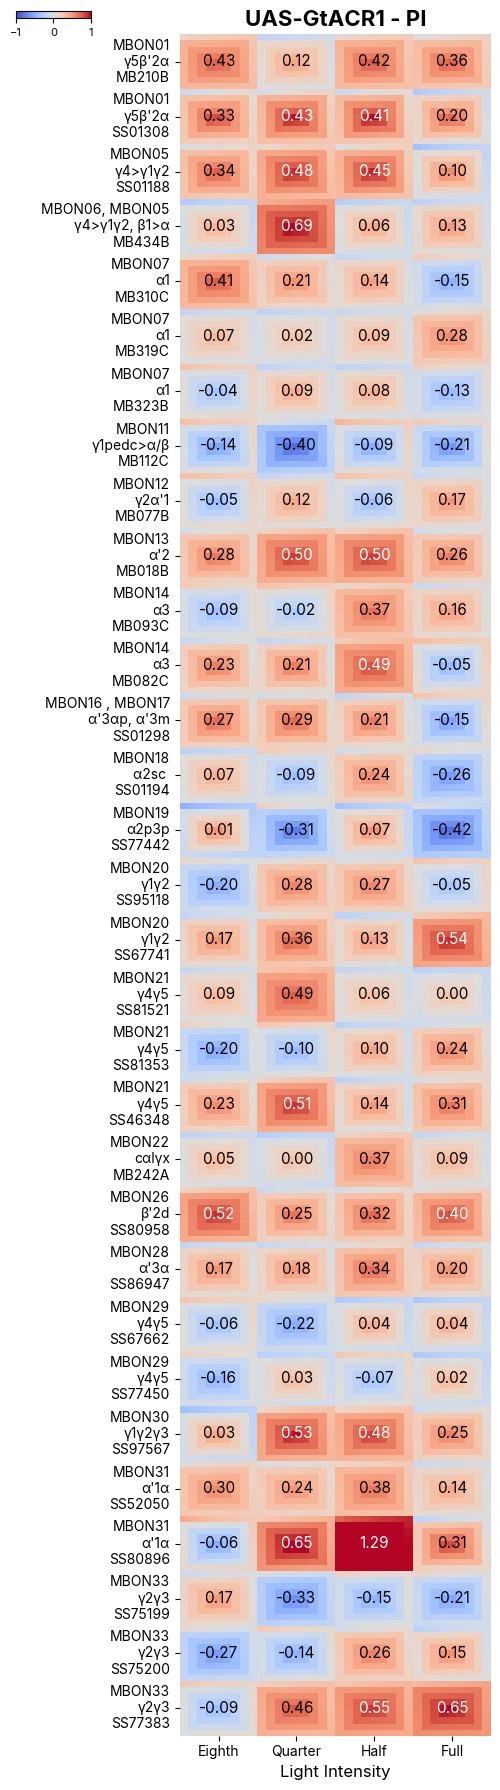

In [11]:
metric = METRICS[0]  # PI_Hg_OSAR

if responder == "ACR":
    responderrename = "UAS-GtACR1"
    colormap = "coolwarm"
if responder == "Chrimson2":
    responderrename = "UAS-CsChrimson"
    colormap = "coolwarm"
    
fig, ax, mbons, vals = create_vortexmap(
    osar_data, responder, metric,
    lobelocation=lobelocation,          
    figsize=(5, 18),
    cmap=colormap,
      

    title=f'{responderrename} - {METRIC_DISPLAY[metric]}',
    title_fontsize=16, title_fontweight='bold',

    xlabel='Light Intensity', xlabel_fontsize=12,
    xticklabels_fontsize=10, xticklabels_rotation=0,

    ylabel=' ',
    yticklabels_fontsize=10, yticklabels_rotation=0,
    yticklabels_sep='\n',
 
    annot=True, annot_fontsize=11, annot_fmt='.2f',  # format: .2f, .3f, .1e, etc.
    # Colorbar - precise x,y positioning (0-1 figure coords)
    cbar=True, cbar_label=" ", cbar_orientation='horizontal',
    cbar_x=0.02, cbar_y=0.987, cbar_width=0.15, cbar_height=0.004, cbar_ticks=[-1, 0, 1],
    cbar_labelsize=10, cbar_ticksize=8
)
mpl.rcParams['svg.fonttype'] = 'none' 
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\Singlemetricvortexmapcomp_" + date + "_" + responder + ".svg")
plt.show()

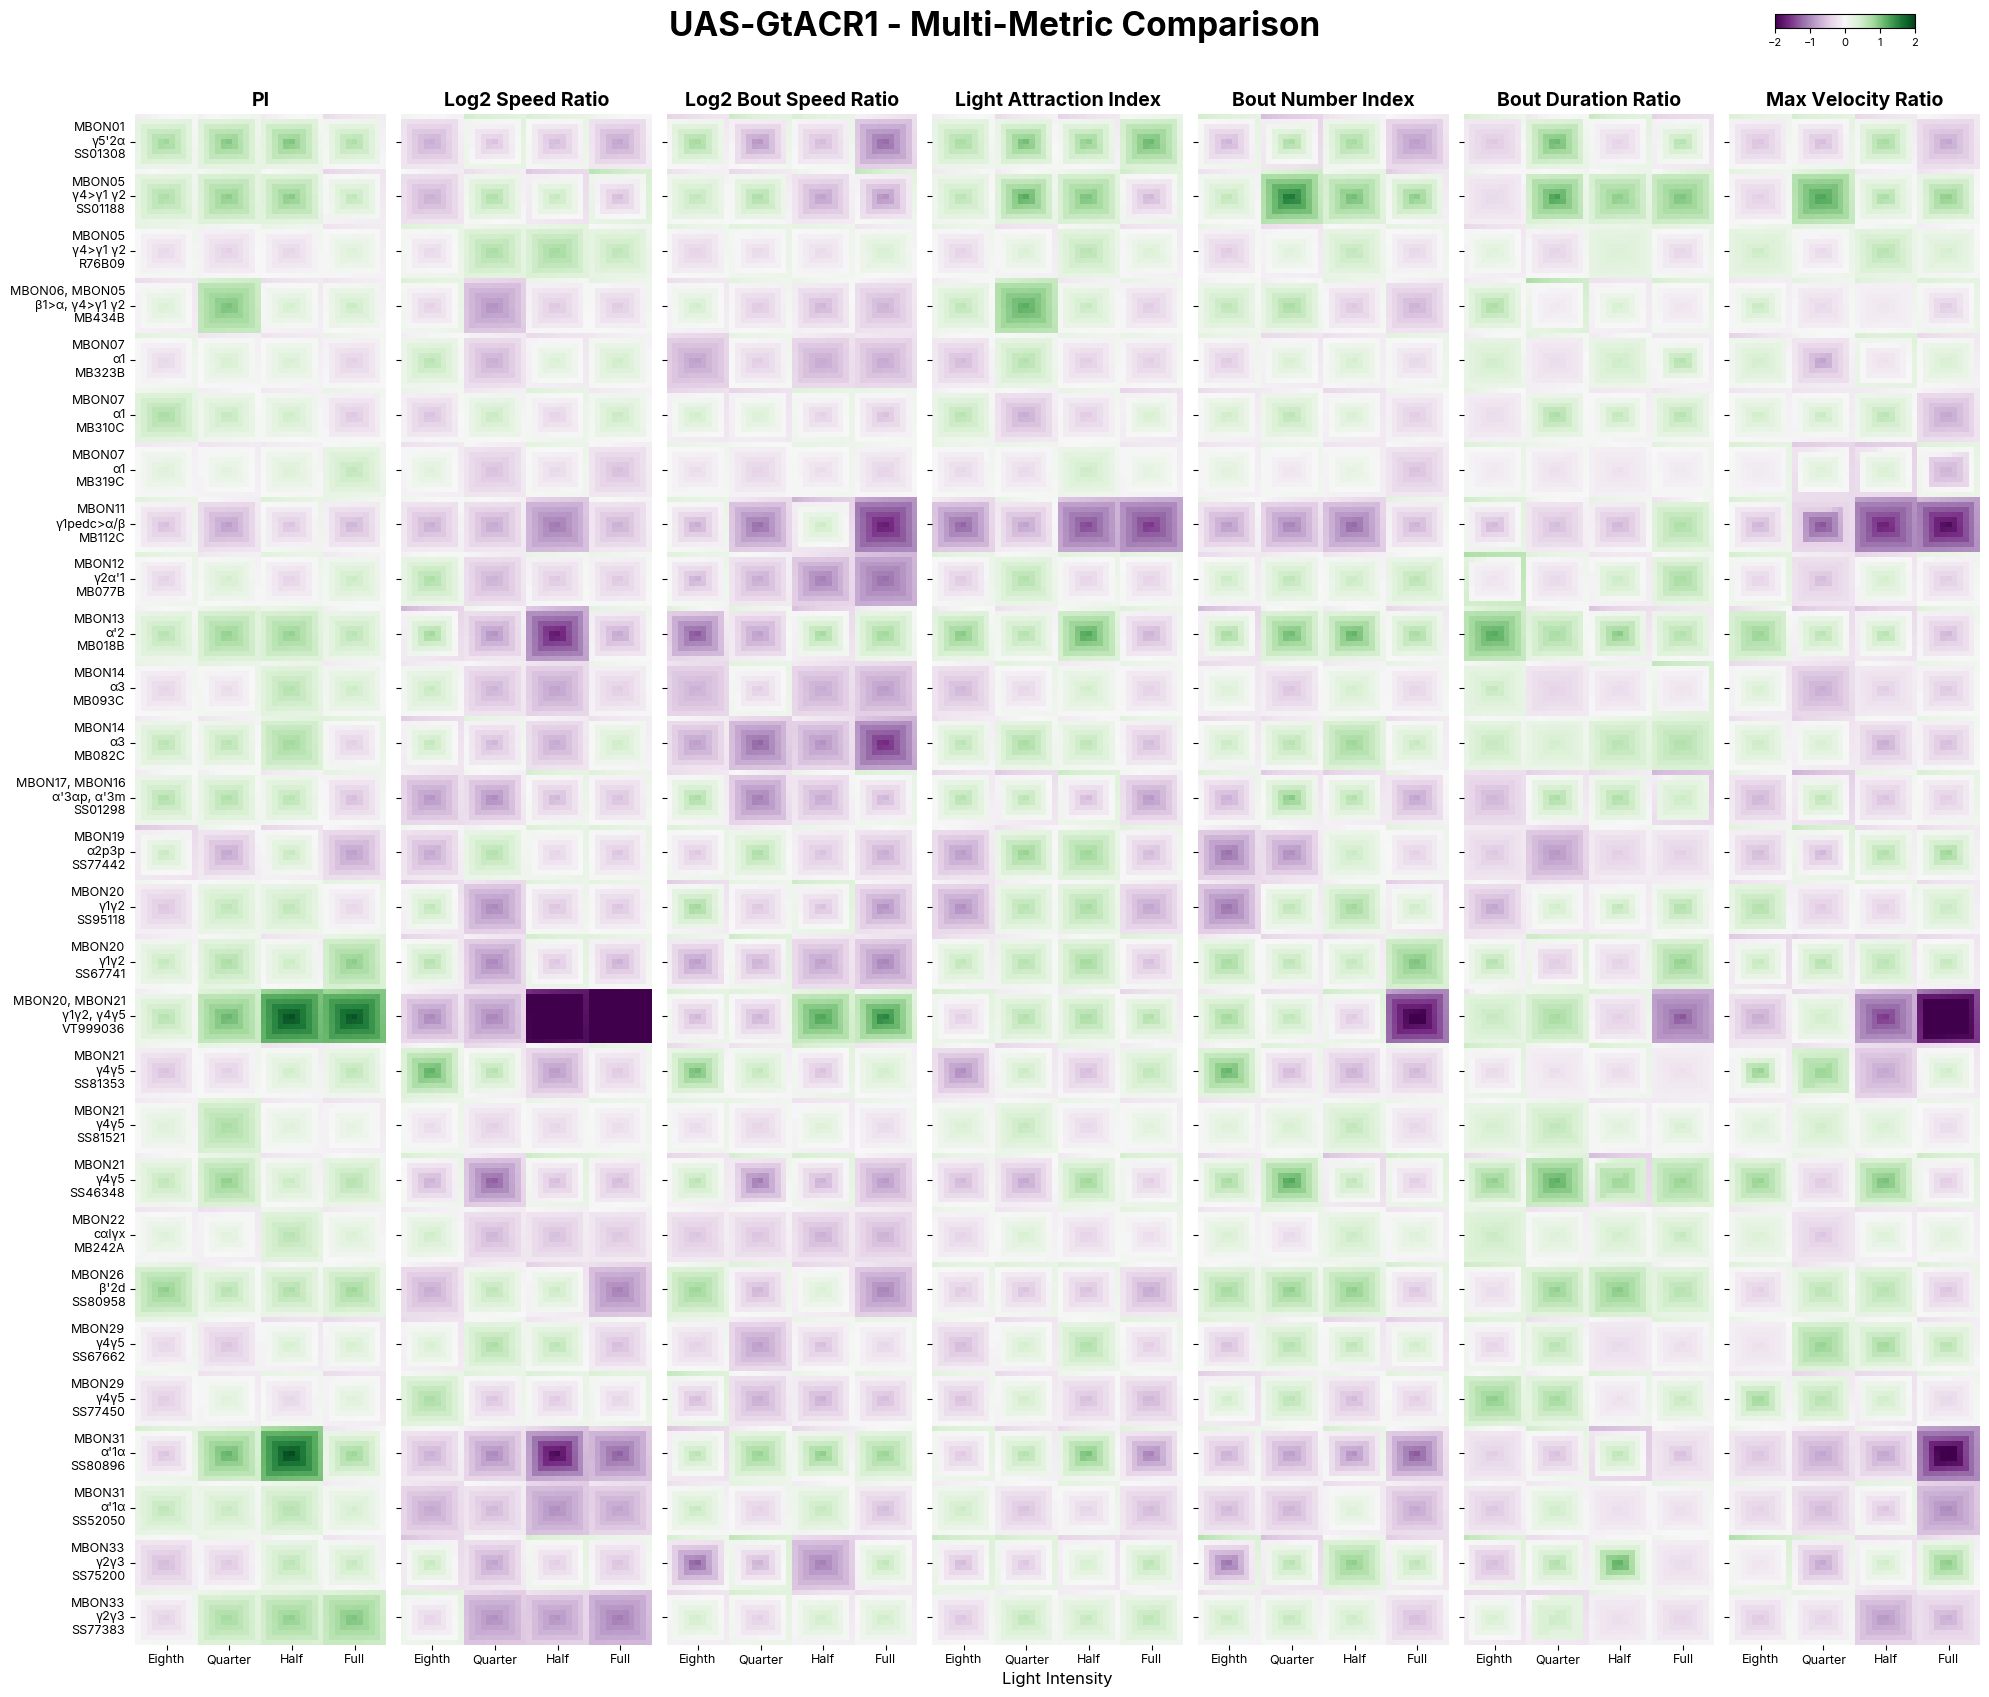

In [ ]:

metrics_to_plot = METRICS[:-2]  # First 3 metrics

responder = "ACR"

if responder == "ACR":
    responderrename = "UAS-GtACR1"
    colormap = "PRGn"
if responder == "Chrimson2":
    responderrename = "UAS-CsChrimson"
    colormap = "coolwarm"

fig, axes, mbons, vals = create_multi_vortexmap(
    osar_data, responder, metrics_to_plot,
    lobelocation=lobelocation,
    figsize=(20, 18),
    cmap= colormap,
    vmin = -2.0,
    vmax = 2.0,
    layout_rect=[0, 0.05, 1, 0.98],
    
    # Overall title
    title=responderrename + ' - Multi-Metric Comparison',
    title_fontsize=24, title_fontweight='bold',
    
    # Subplot titles (one per metric)
    subplot_titles=None,  # Uses METRIC_DISPLAY by default
    subplot_title_fontsize=14, subplot_title_fontweight='bold',
    
    # X-axis
    xlabel='Light Intensity', xlabel_fontsize=12,
    xticklabels_fontsize=9, xticklabels_rotation=0,
    
    # Y-axis (only on leftmost plot)
    yticklabels_fontsize=9, yticklabels_rotation=0,
    yticklabels_sep='\n',
    
    # Annotations
    annot=False, 
    
    # Colorbar
    cbar=True, cbar_label=" ", cbar_orientation='horizontal',
    cbar_x=0.89, cbar_y=0.98, cbar_width=0.07, cbar_height=0.008, cbar_ticks=[-2, -1, 0, 1, 2],
    cbar_labelsize=15, cbar_ticksize=8
)

plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\Multimetricvortexmapcomp_" + date + "_" + responder + ".svg")

plt.show()

## Light intensity range metrics

In [12]:
from scipy import stats

def compute_linear_r_squared(values):
    """Compute R² for linear fit across 4 intensity levels."""
    x = np.array([0, 1, 2, 3])
    y = np.array(values)
    if len(y) != 4 or any(np.isnan(y)):
        return np.nan
    return stats.linregress(x, y).rvalue ** 2

def classify_trajectory_shape(values):
    """Classify trajectory shape. Returns (shape_category, direction)."""
    if any(v is None or np.isnan(v) for v in values):
        return "Missing data", None
    
    eighth, quarter, half, full = values
    max_val, min_val = max(values), min(values)
    response_range = max_val - min_val
    
    # Slopes between consecutive points
    d1 = quarter - eighth   # Eighth → Quarter
    d2 = half - quarter     # Quarter → Half
    d3 = full - half        # Half → Full
    
    # 1. NEGLIGIBLE: ALL |values| < 0.2
    if all(abs(v) < 0.2 for v in values):
        return "Negligible", None
    
    # 2. LINEAR: R² >= 0.6
    r_squared = compute_linear_r_squared(values)
    if not np.isnan(r_squared) and r_squared >= 0.6:
        return "Linear", "positive" if full > eighth else "negative"
    
    # 3. VARIABLE: middle points at opposite extremes
    if (quarter == max_val and half == min_val) or (quarter == min_val and half == max_val):
        return "Variable", None
    
    # 4. U-SHAPED: response_range > 0.2 AND middle transition smaller than both outer transitions
    #    AND min/max is in the middle (quarter or half)
    if response_range > 0.2 and abs(d2) < abs(d1) and abs(d2) < abs(d3):
        if min_val == quarter or min_val == half:
            return "U-shaped", "positive"  # U (dip in middle)
        if max_val == quarter or max_val == half:
            return "U-shaped", "negative"  # Inverted U (peak in middle)
    
    # 5. LINEAR (fallback): endpoints span full range OR response_range > 0.25
    if abs(full - eighth) >= response_range or response_range > 0.25:
        return "Linear", "positive" if full > eighth else "negative"
    
    # 6. FLAT (default)
    return "Flat", None

## single plot curve classification

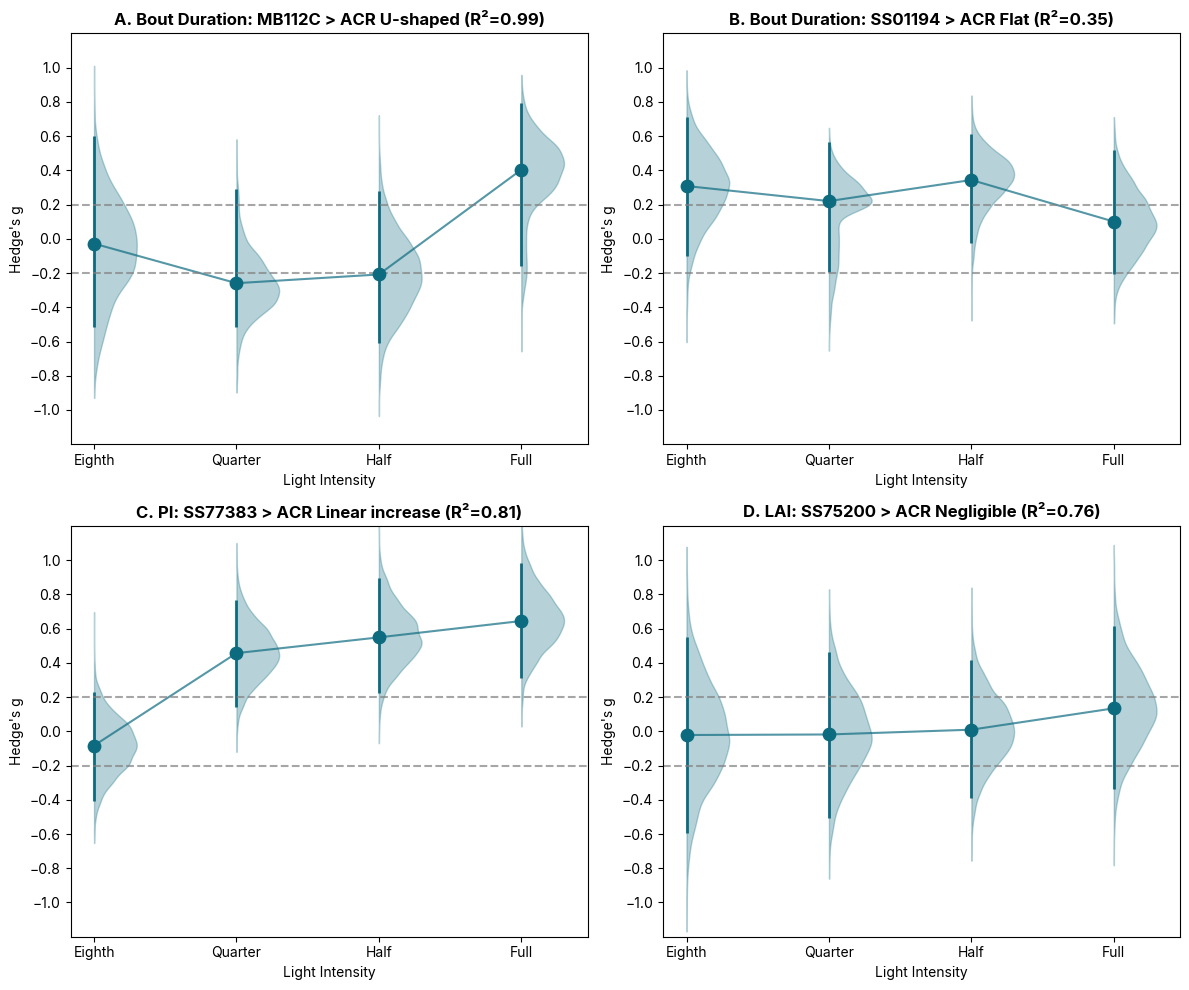

In [134]:
from scipy import stats

intensities = ["Eighth", "Quarter", "Half", "Full"]
x_pos = np.array([0, 1, 2, 3])

metrics_to_search = ["PI_Hg_OSAR", "Light Attraction Index_Hg_OSAR", "Bout Number Index_Hg_OSAR",
                     "Bout Duration ratio_Hg_OSAR", "Max Velocity_Hg_OSAR"]
metric_display = {"PI_Hg_OSAR": "PI", "Light Attraction Index_Hg_OSAR": "LAI",
                  "Bout Number Index_Hg_OSAR": "Bout Number", "Bout Duration ratio_Hg_OSAR": "Bout Duration",
                  "Max Velocity_Hg_OSAR": "Max Velocity"}

def get_avg_ci_width(osar_data, responder, metric, mbon_name):
    total_width, count = 0, 0
    for intensity in intensities:
        effect, ci_low, ci_high = get_effect(osar_data, responder, intensity, metric, mbon_name)
        if effect is not None and ci_low is not None and ci_high is not None:
            total_width += (ci_high - ci_low)
            count += 1
    return total_width / count if count > 0 else float('inf')

def get_best_example(pattern_df, osar_data, responder, shape_category, direction=None, max_abs_value=1.0, require_large_effect=True):
    best, best_score = None, -float('inf')
    for metric in metrics_to_search:
        subset = pattern_df[(pattern_df['Responder'] == responder) &
                            (pattern_df['Metric'] == metric) &
                            (pattern_df['Shape_Category'] == shape_category) &
                            (abs(pattern_df['Eighth']) <= max_abs_value) &
                            (abs(pattern_df['Quarter']) <= max_abs_value) &
                            (abs(pattern_df['Half']) <= max_abs_value) &
                            (abs(pattern_df['Full']) <= max_abs_value)].copy()
        if direction is not None:
            subset = subset[subset['Direction'] == direction]
        for _, row in subset.iterrows():
            values = [row['Eighth'], row['Quarter'], row['Half'], row['Full']]
            effect_range = max(values) - min(values)
            if require_large_effect and max(abs(v) for v in values) < 0.25:
                continue
            r2 = row['R_squared'] if not pd.isna(row['R_squared']) else 0
            score = effect_range * 2 + r2 * 1.5 - get_avg_ci_width(osar_data, responder, metric, row['MBON']) * 0.5
            if score > best_score:
                best_score = score
                best = row.copy()
                best['Metric_Used'] = metric
    return best

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# (shape_category, direction, display_name)
shapes_to_plot = [
    ("U-shaped", "positive", "U-shaped"),
    ("Flat", None, "Flat"),
    ("Linear", "positive", "Linear increase"),
    ("Negligible", None, "Negligible")
]

for idx, (shape, direction, display_name) in enumerate(shapes_to_plot):
    ax = axes[idx]
    require_large = shape not in ["Flat", "Negligible"]
    example = get_best_example(pattern_df, osar_data, "ACR", shape, direction=direction, require_large_effect=require_large)

    if example is not None:
        mbon_name, metric_used = example['MBON'], example['Metric_Used']
        values = [example['Eighth'], example['Quarter'], example['Half'], example['Full']]
        r2_val = example['R_squared'] if not pd.isna(example['R_squared']) else 0
        for i, intensity in enumerate(intensities):
            bootstrap = get_bootstrap(osar_data, "ACR", intensity, metric_used, mbon_name)
            bootstrap = bootstrap[~np.isnan(bootstrap)]
            effect, ci_low, ci_high = get_effect(osar_data, "ACR", intensity, metric_used, mbon_name)
            if len(bootstrap) > 1 and effect is not None:
                kde = stats.gaussian_kde(bootstrap)
                y_kde = np.linspace(min(bootstrap), max(bootstrap), 100)
                x_kde = kde(y_kde) / kde(y_kde).max() * 0.3
                ax.fill_betweenx(y_kde, x_pos[i], x_pos[i] + x_kde, color='#0D6B80', alpha=0.3)
                ax.vlines(x_pos[i], ci_low, ci_high, color='#0D6B80', linewidth=2)
                ax.scatter(x_pos[i], effect, color='#0D6B80', s=80, zorder=5)
        ax.plot(x_pos, values, '-', color='#0D6B80', linewidth=1.5, alpha=0.7)
        ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.7)
        ax.axhline(y=-0.2, color='gray', linestyle='--', alpha=0.7)
        ax.set_title(f"{chr(65+idx)}. {metric_display.get(metric_used, metric_used.split('_')[0])}: {mbon_name} > ACR {display_name} (R²={r2_val:.2f})", fontsize=12, fontweight='bold')
    else:
        ax.set_title(f"{chr(65+idx)}. No example found - {display_name}", fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(intensities)
    ax.set_yticks([-1.0, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel("Light Intensity")
    ax.set_ylabel("Hedge's g")

plt.tight_layout()
plt.show()

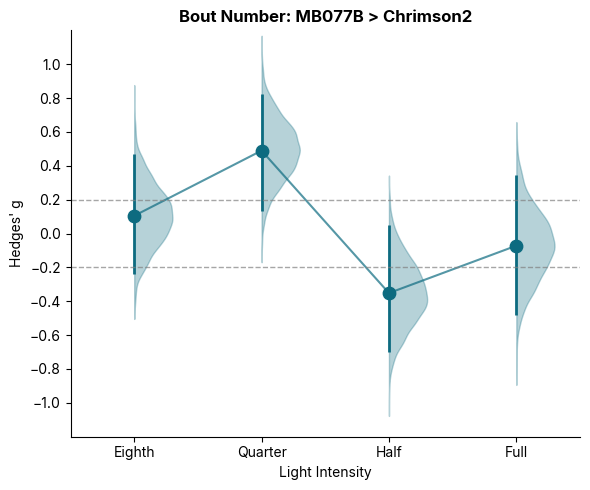

In [155]:
# Single metric
mbon_to_plot = "MB077B"  
metric_to_plot = "Bout Number Index_Hg_OSAR"  
responder_to_plot = "Chrimson2"  

from scipy import stats
intensities = ["Eighth", "Quarter", "Half", "Full"]
x_pos = np.array([0, 1, 2, 3])

fig, ax = plt.subplots(figsize=(6, 5))

values = []
for i, intensity in enumerate(intensities):
    bootstrap = get_bootstrap(osar_data, responder_to_plot, intensity, metric_to_plot, mbon_to_plot)
    bootstrap = bootstrap[~np.isnan(bootstrap)]
    effect, ci_low, ci_high = get_effect(osar_data, responder_to_plot, intensity, metric_to_plot, mbon_to_plot)
    values.append(effect)

    if len(bootstrap) > 1 and effect is not None:
        kde = stats.gaussian_kde(bootstrap)
        y_kde = np.linspace(min(bootstrap), max(bootstrap), 100)
        x_kde = kde(y_kde)
        x_kde = x_kde / x_kde.max() * 0.3
        ax.fill_betweenx(y_kde, x_pos[i], x_pos[i] + x_kde, color="#0D6B80", alpha=0.3)
        ax.vlines(x_pos[i], ci_low, ci_high, color="#0D6B80", linewidth=2)
        ax.scatter(x_pos[i], effect, color="#0D6B80", s=80, zorder=5)

ax.plot(x_pos, values, "-", color="#0D6B80", linewidth=1.5, alpha=0.7)
ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.7, linewidth=1)
ax.axhline(y=-0.2, color='gray', linestyle='--', alpha=0.7, linewidth=1)
ax.set_xticks(x_pos)
ax.set_xticklabels(intensities)
ax.set_xlim(-0.5, 3.5)
ax.set_xlabel("Light Intensity")
ax.set_ylabel("Hedges' g")
ax.set_yticks([-1.0, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylim(-1.2, 1.2)
ax.set_title(f"{metric_short_names.get(metric_to_plot, metric_to_plot)}: {mbon_to_plot} > {responder_to_plot}", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
#plt.savefig(os.path.join(save_path, mbon_to_plot + " x " + responder_to_plot + "_one_example_shape.svg"), bbox_inches='tight')
plt.show()

## Bubble matrix

Global max Response Range: 2.327


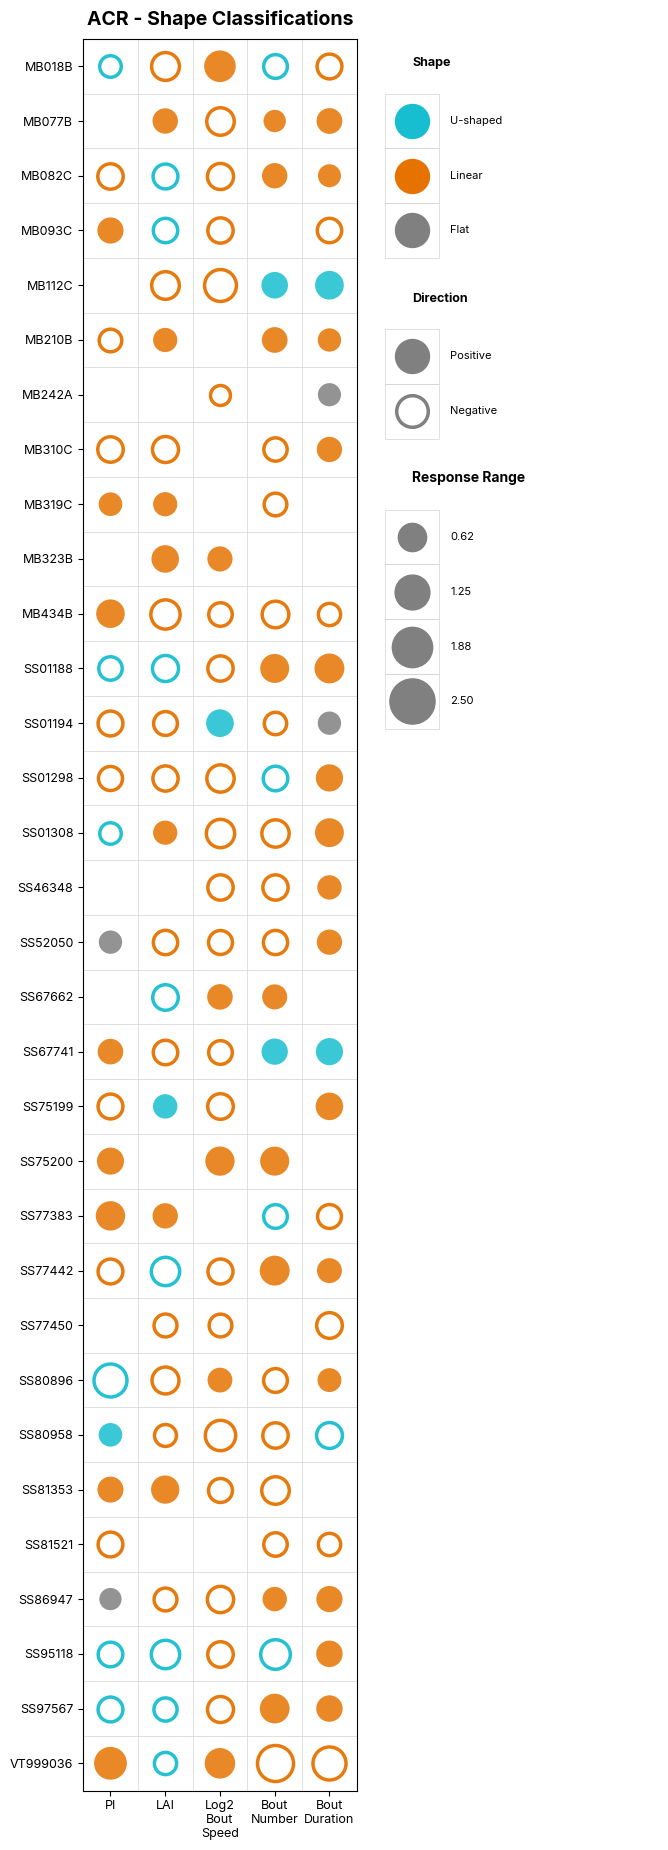

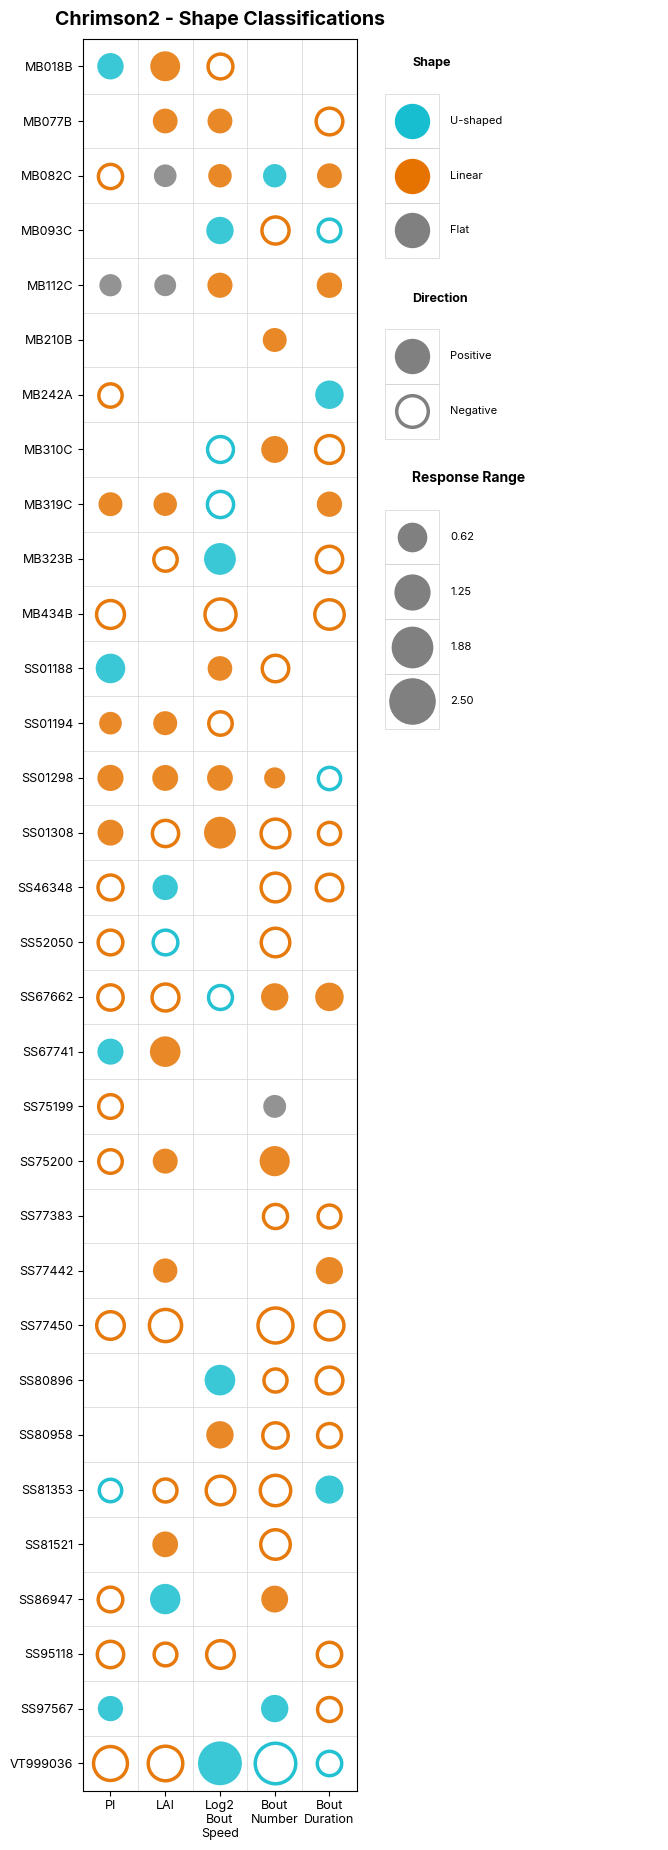

In [152]:
mpl.rcParams['svg.fonttype'] = 'none'

metric_short_names = {
    "PI_Hg_OSAR": "PI", "Light Attraction Index_Hg_OSAR": "LAI",
    "Log2 Bout Speed ratio_Hg_OSAR": "Log2 Bout Speed",
    "Bout Number Index_Hg_OSAR": "Bout Number",
    "Bout Duration ratio_Hg_OSAR": "Bout Duration"}
metrics_order = list(metric_short_names.keys())
shape_colors = {'U': '#17BECF', 'L': '#E67300', 'F': '#808080'}

# Create Shape_Code and Response_Range columns
def get_code(row):
    shape, direction = row['Shape_Category'], row['Direction']
    if shape == 'Linear': return 'L' if direction == 'positive' else '-L'
    if shape == 'U-shaped': return 'U' if direction == 'positive' else '-U'
    return {'Flat': 'F', 'Negligible': 'N', 'Variable': 'V'}.get(shape, 'M')

pattern_df['Shape_Code'] = pattern_df.apply(get_code, axis=1)
pattern_df['Response_Range'] = pattern_df.apply(
    lambda r: max(r['Eighth'], r['Quarter'], r['Half'], r['Full']) - min(r['Eighth'], r['Quarter'], r['Half'], r['Full'])
    if not any(pd.isna([r['Eighth'], r['Quarter'], r['Half'], r['Full']])) else np.nan, axis=1)

global_max_range = pattern_df[pattern_df['Metric'].isin(metrics_order)]['Response_Range'].max()
print(f"Global max Response Range: {global_max_range:.3f}")

for resp in ["ACR", "Chrimson2"]:
    resp_data = pattern_df[(pattern_df['Responder'] == resp) & (pattern_df['Metric'].isin(metrics_order))].copy()
    mbons_sorted, n_metrics = sorted(resp_data['MBON'].unique()), len(metrics_order)
    n_mbons = len(mbons_sorted)

    cell_size, outline_width = 0.55, 2.5
    max_size = np.pi * (cell_size * 72 * 0.9 / 2) ** 2
    hollow_max_size = np.pi * ((cell_size * 72 * 0.9 - outline_width) / 2) ** 2

    fig, (ax, ax_leg) = plt.subplots(1, 2, figsize=(n_metrics * cell_size * 2 + 1.5, n_mbons * cell_size + 1.0))
    ax.set_xlim(0, n_metrics); ax.set_ylim(0, n_mbons); ax.set_aspect('equal')
    for i in range(n_mbons + 1): ax.axhline(y=i, color='lightgray', linewidth=0.5)
    for j in range(n_metrics + 1): ax.axvline(x=j, color='lightgray', linewidth=0.5)

    for i, mbon in enumerate(mbons_sorted):
        for j, metric in enumerate(metrics_order):
            row = resp_data[(resp_data['MBON'] == mbon) & (resp_data['Metric'] == metric)]
            if len(row) == 0: continue
            row = row.iloc[0]
            if row['Shape_Category'] == "Negligible" or row['Shape_Code'] == "V": continue

            rng_norm = (row['Response_Range'] / global_max_range) if global_max_range > 0 and not pd.isna(row['Response_Range']) else 0
            color = shape_colors.get(row['Shape_Code'].replace('-', ''), '#808080')
            
            if row['Direction'] in ["positive", ""]:
                ax.scatter(j + 0.5, i + 0.5, s=max_size * (0.2 + 0.8 * rng_norm), c=color, edgecolors='none', alpha=0.85)
            else:
                ax.scatter(j + 0.5, i + 0.5, s=hollow_max_size * (0.2 + 0.8 * rng_norm), facecolors='white', edgecolors=color, linewidths=outline_width, alpha=0.95)

    ax.set_xticks([j + 0.5 for j in range(n_metrics)])
    ax.set_xticklabels([metric_short_names[m].replace(' ', '\n') for m in metrics_order], fontsize=9)
    ax.set_yticks([i + 0.5 for i in range(n_mbons)]); ax.set_yticklabels(mbons_sorted, fontsize=9)
    ax.set_title(f"{resp} - Shape Classifications", fontsize=14, fontweight='bold', pad=10); ax.invert_yaxis()

    # Legend
    ax_leg.set_xlim(0, n_metrics); ax_leg.set_ylim(0, n_mbons); ax_leg.set_aspect('equal'); ax_leg.axis('off'); ax_leg.invert_yaxis()
    ex_size, hollow_ex = max_size * 0.6, hollow_max_size * 0.6
    row_idx = 0.5
    
    ax_leg.text(0.5, row_idx, "Shape", ha='left', fontsize=9, fontweight='bold'); row_idx += 1
    for code, col, name in [('U', '#17BECF', 'U-shaped'), ('L', '#E67300', 'Linear'), ('F', '#808080', 'Flat')]:
        ax_leg.add_patch(plt.Rectangle((0, row_idx - 0.5), 1, 1, fill=False, edgecolor='lightgray', linewidth=0.5))
        ax_leg.scatter(0.5, row_idx, s=ex_size, c=col); ax_leg.text(1.2, row_idx, name, va='center', fontsize=8); row_idx += 1

    row_idx += 0.3; ax_leg.text(0.5, row_idx, "Direction", ha='left', fontsize=9, fontweight='bold'); row_idx += 1
    for fill, edge, lbl in [(True, None, "Positive"), (False, '#808080', "Negative")]:
        ax_leg.add_patch(plt.Rectangle((0, row_idx - 0.5), 1, 1, fill=False, edgecolor='lightgray', linewidth=0.5))
        if fill: ax_leg.scatter(0.5, row_idx, s=ex_size, c='#808080')
        else: ax_leg.scatter(0.5, row_idx, s=hollow_ex, facecolors='white', edgecolors=edge, linewidths=outline_width)
        ax_leg.text(1.2, row_idx, lbl, va='center', fontsize=8); row_idx += 1

    row_idx += 0.3; ax_leg.text(0.5, row_idx, "Response Range", ha='left', fontsize=10, fontweight='bold'); row_idx += 1
    legend_max = np.ceil(global_max_range * 4) / 4
    for tick_val in [legend_max * f for f in [0.25, 0.5, 0.75, 1.0]]:
        ax_leg.add_patch(plt.Rectangle((0, row_idx - 0.5), 1, 1, fill=False, edgecolor='lightgray', linewidth=0.5))
        ax_leg.scatter(0.5, row_idx, s=max_size * (0.2 + 0.8 * tick_val / global_max_range), c='#808080')
        ax_leg.text(1.2, row_idx, f"{tick_val:.2f}", va='center', fontsize=8); row_idx += 1

    plt.tight_layout()
    plt.savefig(os.path.join(save_path, resp + "_bubblematrix.svg"), bbox_inches='tight')
    plt.show()

## bubble matrix table

In [137]:
# Pivot to shape code table (Shape_Code already created in bubble matrix cell)
shape_summary_df = pattern_df[pattern_df['Metric'].isin(metric_short_names.keys())].pivot_table(
    index=['MBON','Responder'], columns='Metric', values='Shape_Code', aggfunc='first').reset_index()
shape_summary_df.columns = ['MBON','Responder'] + [metric_short_names[c] for c in shape_summary_df.columns[2:]]
print(shape_summary_df.to_string())

        MBON  Responder Bout Duration Bout Number LAI Log2 Bout Speed  PI
0     MB018B        ACR            -L          -U  -L               L  -U
1     MB018B  Chrimson2             V           V   L              -L   U
2     MB077B        ACR             L           L   L              -L   N
3     MB077B  Chrimson2            -L           V   L               L   V
4     MB082C        ACR             L           L  -U              -L  -L
5     MB082C  Chrimson2             L           U   F               L  -L
6     MB093C        ACR            -L           N  -U              -L   L
7     MB093C  Chrimson2            -U          -L   N               U   V
8     MB112C        ACR             U           U  -L              -L   V
9     MB112C  Chrimson2             L           V   F               L   F
10    MB210B        ACR             L           L   L               V  -L
11    MB210B  Chrimson2             N           L   N               V   N
12    MB242A        ACR             F 

In [139]:
# Count L and Q per responder
for resp in ['ACR', 'Chrimson2']:
    codes = shape_summary_df[shape_summary_df['Responder']==resp].iloc[:,2:].values.flatten()
    counts = {k: sum(1 for c in codes if c.replace('-','')==k) for k in ['L','U','F','N','V','M']}
    total = len(codes)
    print(f"{resp}: L={counts['L']}, U={counts['U']}, F={counts['F']}, N={counts['N']}, V={counts['V']} | L={counts['L']}/{total} |  U={counts['U']}/{total}")

ACR: L=104, U=26, F=4, N=15, V=11 | L=104/160 |  U=26/160
Chrimson2: L=78, U=23, F=4, N=16, V=39 | L=78/160 |  U=23/160


## Pairwise correlation

## categorical analysis

In [87]:
categories = {
    "Cat 1A (Pure Valence)": {
        "ACT": ['MB018B', 'SS01194', 'SS67741', 'SS75199'],
        "INH": ['SS77450']
    },
    "Cat 1B (Valence Biases Locomotion)": {
        "ACT": ['MB319C', 'SS67662', 'SS97567'],
        "INH": ['MB319C', 'SS01194', 'SS95118', 'SS81353', 'SS97567', 'SS77383']
    },
    "Cat 2 (Ambiguous)": {
        "ACT": ['MB310C', 'MB112C', 'MB077B', 'MB093C', 'MB082C', 'SS01298', 'SS77442', 'SS95118', 'SS46348', 'SS52050', 'SS80896', 'SS77383'],
        "INH": ['MB210B', 'MB434B', 'MB323B', 'MB310C', 'MB018B', 'MB093C', 'SS01298', 'SS77442', 'MB242A', 'SS86947', 'SS52050', 'SS75199']
    },
    "Cat 3 (Locomotion Biases Valence)": {
        "ACT": ['SS01308', 'SS01188', 'MB434B', 'MB323B', 'VT999036', 'SS81353', 'SS81521', 'SS80958', 'SS77450', 'SS75200'],
        "INH": ['SS01308', 'SS01188', 'MB112C', 'MB077B', 'MB082C', 'SS67741', 'SS46348', 'VT999036', 'SS80958', 'SS80896']
    },
    "Cat 4 (No Effect)": {
        "ACT": ['MB210B', 'MB242A', 'SS86947'],
        "INH": ['SS81521', 'SS67662', 'SS75200']
    },
    
    "Cat 5": {
        "ACT": ['SS81353', 'SS01188']
        
    },
}


responder_state_map = {
    "ACR": "INH",
    "Chrimson2": "ACT"
}

# Metric pairs for categorical analysis
cat_metric_pairs = [
    ("PI_Hg_OSAR", "Light Attraction Index_Hg_OSAR", "PI_LAI"),
    ("PI_Hg_OSAR", "Log2 Bout Speed ratio_Hg_OSAR", "PI_Speed"),
    ("PI_Hg_OSAR", "Bout Number Index_Hg_OSAR", "PI_BoutNum"),
    ("PI_Hg_OSAR", "Bout Duration ratio_Hg_OSAR", "PI_BoutDur"),
    ("Light Attraction Index_Hg_OSAR", "Log2 Bout Speed ratio_Hg_OSAR", "LAI_Speed"),
    ("Light Attraction Index_Hg_OSAR", "Bout Number Index_Hg_OSAR", "LAI_BoutNum"),
    ("Light Attraction Index_Hg_OSAR", "Bout Duration ratio_Hg_OSAR", "LAI_BoutDur"),
]

cat_intensities = ["Eighth", "Quarter", "Half", "Full"]

def get_cat_effect_values(osar_data, responder, metric, mbon):
    """Get 4 effect sizes across intensities for a given MBON/metric."""
    values = []
    for intensity in cat_intensities:
        effect, _, _ = get_effect(osar_data, responder, intensity, metric, mbon)
        values.append(effect)
    return values

def should_omit_pair(values_a, values_b, threshold=0.2):
    """Omission rules:
    1) If EITHER group has ALL 4 values below |threshold| -> omit.
    2) If BOTH groups have 3+ values below |threshold| -> omit."""
    if values_a is None or values_b is None:
        return True
    if any(v is None for v in values_a) or any(v is None for v in values_b):
        return True

    count_a = sum(1 for v in values_a if abs(v) < threshold)
    count_b = sum(1 for v in values_b if abs(v) < threshold)

    # Criterion 1: if EITHER group has all 4 below |threshold| -> omit
    if count_a == 4 or count_b == 4:
        return True

    # Criterion 2: if BOTH groups have 3+ below |threshold| -> omit
    if count_a >= 3 and count_b >= 3:
        return True

    return False

def compute_categorical_correlation_table(osar_data, r_threshold=0.8):
    """Generate pairwise correlation table for all categories.
    ACR -> INH MBONs only, Chrimson2 -> ACT MBONs only.
    Only shows r values where |r| >= r_threshold."""
    from scipy.stats import pearsonr

    rows = []
    for cat_name, states in categories.items():
        for responder, state in responder_state_map.items():
            mbons = states.get(state, [])
            for mbon in mbons:
                row = {"Category": cat_name, "MBON": mbon, "State": state, "Responder": responder}
                for metric1, metric2, col_name in cat_metric_pairs:
                    vals_a = get_cat_effect_values(osar_data, responder, metric1, mbon)
                    vals_b = get_cat_effect_values(osar_data, responder, metric2, mbon)

                    if should_omit_pair(vals_a, vals_b):
                        row[col_name] = "-"
                    else:
                        try:
                            r, _ = pearsonr(vals_a, vals_b)
                            if abs(r) >= r_threshold:
                                row[col_name] = round(r, 2)
                            else:
                                row[col_name] = "-"
                        except:
                            row[col_name] = "-"
                rows.append(row)

    col_order = ["Category", "MBON", "State", "Responder"] + [p[2] for p in cat_metric_pairs]
    df = pd.DataFrame(rows)[col_order]
    return df

def parse_genotype_string(genotype_str):
    parts = genotype_str.strip().split(" x ")
    if len(parts) != 2:
        parts = genotype_str.strip().split(" X ")
    mbon = parts[0].strip()
    responder = parts[1].strip()
    return mbon, responder

def get_genotype_pair_data(osar_data, mbon, responder):
    """Get bootstrap and effect data for all 7 metric pairs for a genotype."""
    metric_pairs_info = [
        ("PI_Hg_OSAR", "Light Attraction Index_Hg_OSAR", "PI", "LAI"),
        ("PI_Hg_OSAR", "Log2 Bout Speed ratio_Hg_OSAR", "PI", "Speed"),
        ("PI_Hg_OSAR", "Bout Number Index_Hg_OSAR", "PI", "BoutNum"),
        ("PI_Hg_OSAR", "Bout Duration ratio_Hg_OSAR", "PI", "BoutDur"),
        ("Light Attraction Index_Hg_OSAR", "Log2 Bout Speed ratio_Hg_OSAR", "LAI", "Speed"),
        ("Light Attraction Index_Hg_OSAR", "Bout Number Index_Hg_OSAR", "LAI", "BoutNum"),
        ("Light Attraction Index_Hg_OSAR", "Bout Duration ratio_Hg_OSAR", "LAI", "BoutDur"),
    ]

    pair_data = []
    for metric1, metric2, label1, label2 in metric_pairs_info:
        vals_a = get_cat_effect_values(osar_data, responder, metric1, mbon)
        vals_b = get_cat_effect_values(osar_data, responder, metric2, mbon)

        r_val = None
        if not should_omit_pair(vals_a, vals_b):
            try:
                from scipy.stats import pearsonr
                r_val, _ = pearsonr(vals_a, vals_b)
            except:
                pass

        pair_data.append({
            "metric1": metric1, "metric2": metric2,
            "label1": label1, "label2": label2,
            "r": r_val
        })

    return pair_data

In [91]:
from scipy import stats

cat_df = compute_categorical_correlation_table(osar_data, r_threshold=0.78)

# Save single CSV
corr_save_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\osar_compiled"
#cat_df.to_csv(os.path.join(corr_save_path, "pairwise_correlations.csv"), index=False)

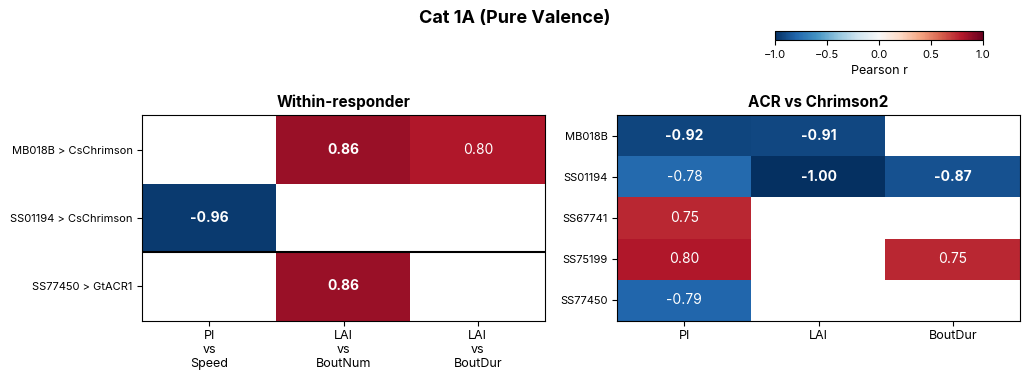

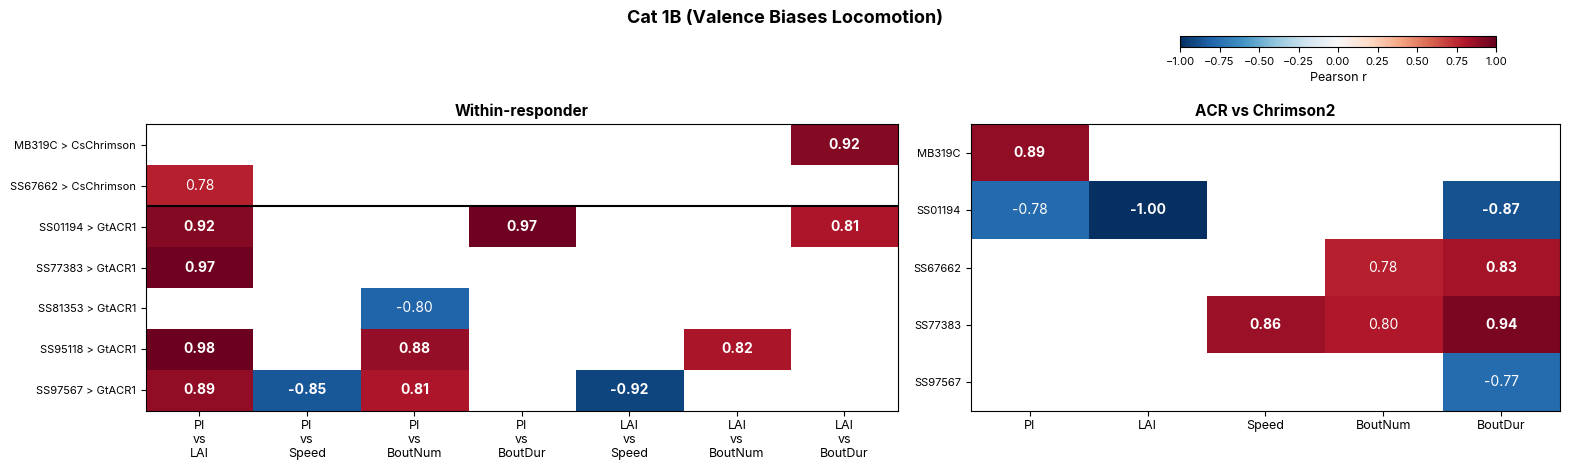

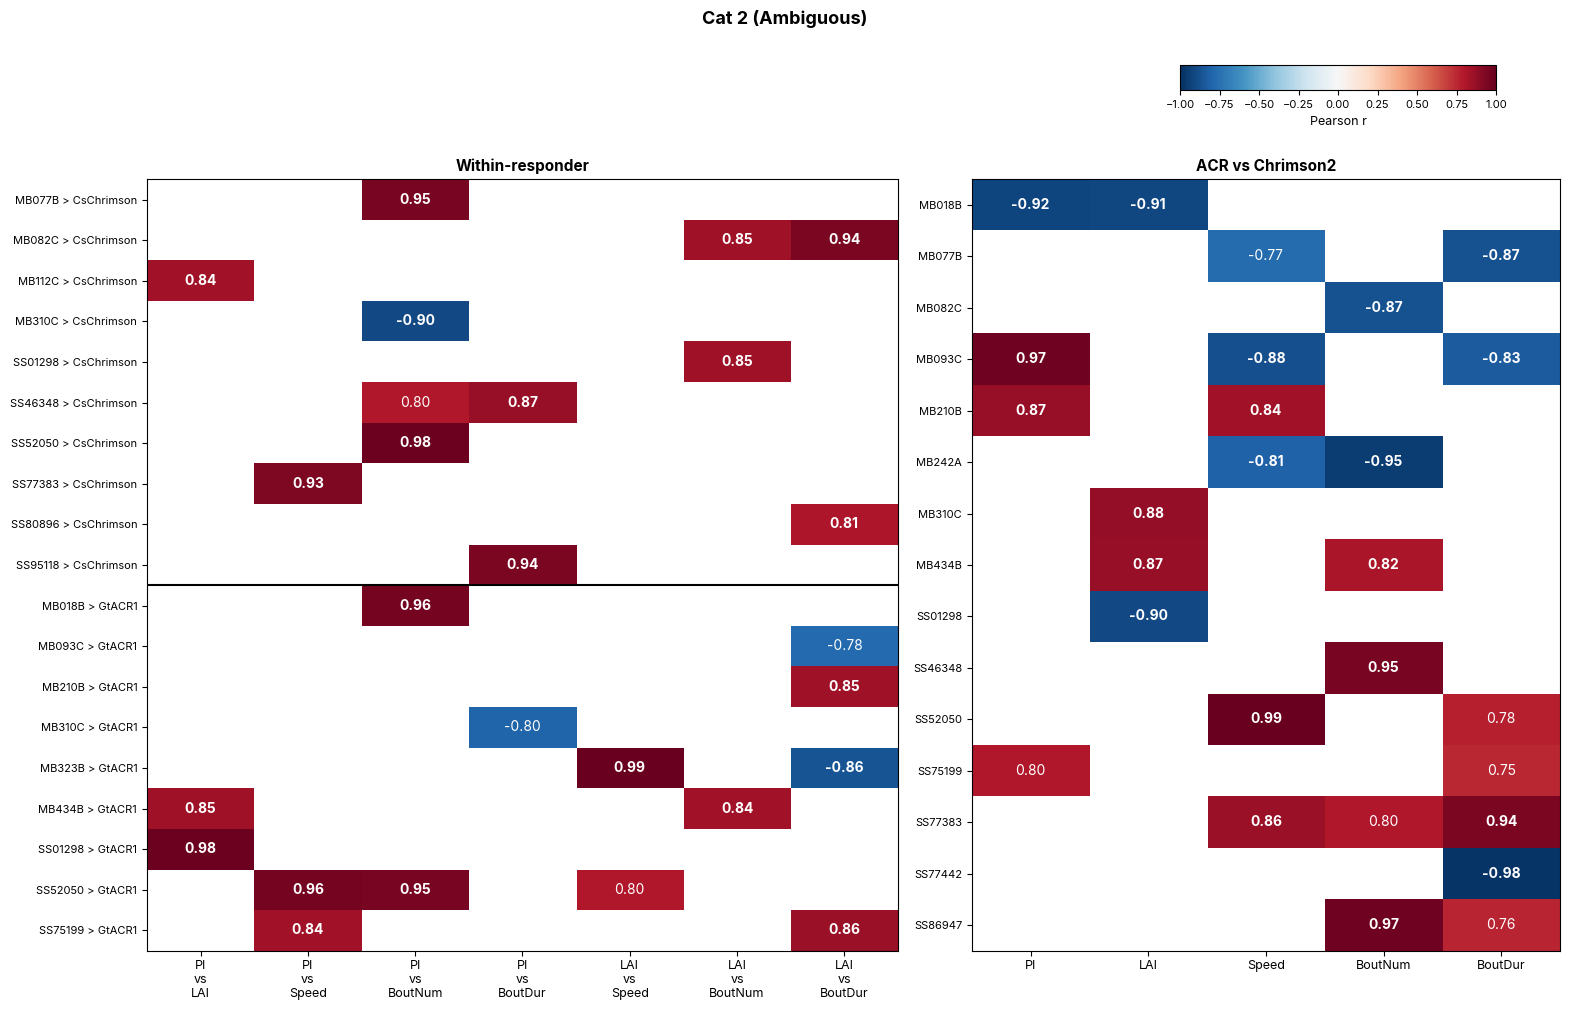

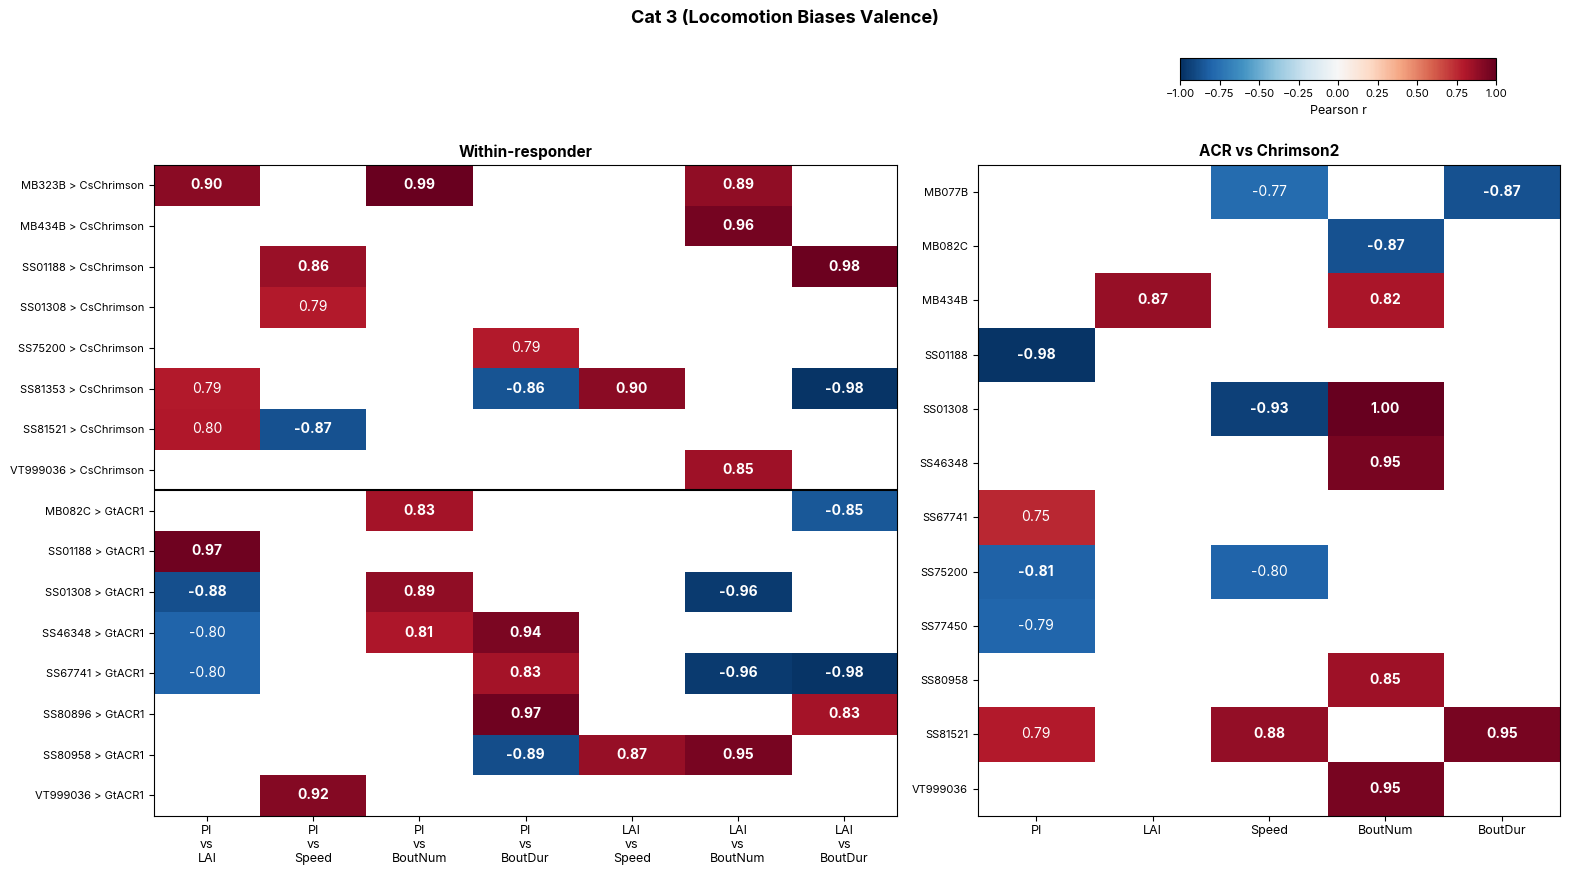

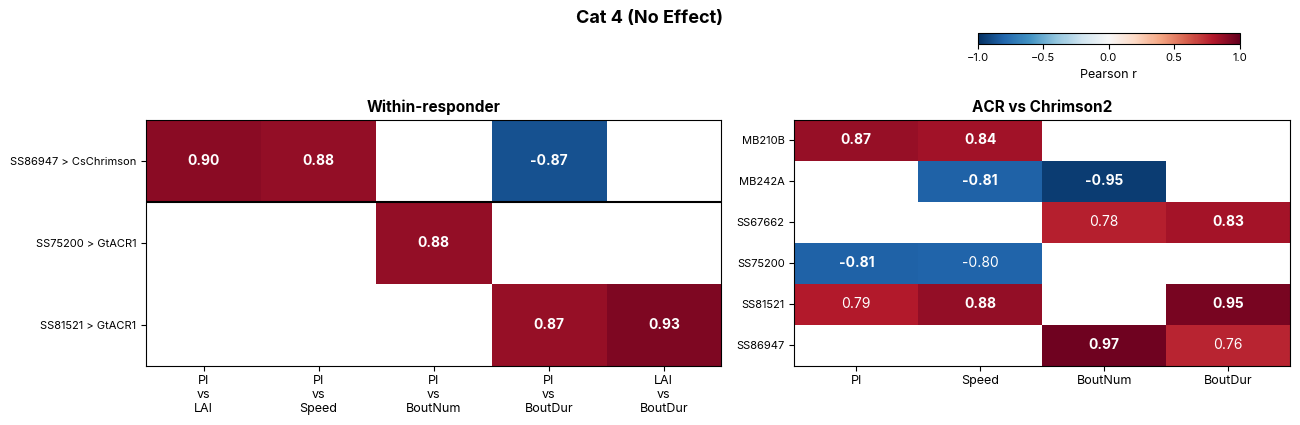

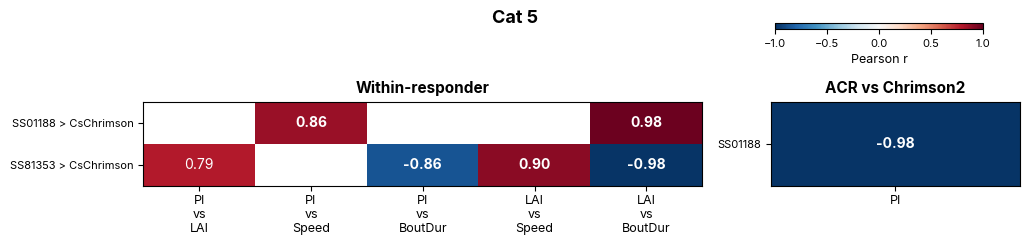

In [92]:
mpl.rcParams['svg.fonttype'] = 'none'
pair_cols = [p[2] for p in cat_metric_pairs]

# Responder display names for y-tick labels
responder_display = {"ACR": "GtACR1", "Chrimson2": "CsChrimson"}

# Metrics for ACR vs Chrimson2 subplot
cross_metrics = [
    ("PI_Hg_OSAR", "PI"),
    ("Light Attraction Index_Hg_OSAR", "LAI"),
    ("Log2 Bout Speed ratio_Hg_OSAR", "Speed"),
    ("Bout Number Index_Hg_OSAR", "BoutNum"),
    ("Bout Duration ratio_Hg_OSAR", "BoutDur"),
]

from scipy.stats import pearsonr

for cat_name in categories.keys():
    cat_subset = cat_df[cat_df['Category'] == cat_name].copy()
    if len(cat_subset) == 0:
        continue

    # Drop rows where ALL pair columns are "-" (no values at all)
    has_value = cat_subset[pair_cols].apply(lambda row: any(isinstance(v, (int, float)) for v in row), axis=1)
    cat_subset = cat_subset[has_value].copy()
    if len(cat_subset) == 0:
        print(f"{cat_name}: no MBONs with |r| >= 0.8, skipping heatmap")
        continue

    # Sort by State (ACT first, then INH) for visual grouping
    cat_subset['state_order'] = cat_subset['State'].map({'ACT': 0, 'INH': 1})
    cat_subset = cat_subset.sort_values(['state_order', 'MBON']).reset_index(drop=True)

    mbons_sp1 = cat_subset['MBON'].tolist()
    responders_list = cat_subset['Responder'].tolist()
    states_list = cat_subset['State'].tolist()
    n_mbons_sp1 = len(mbons_sp1)

    # --- Subplot 1: within-responder metric pair correlations ---
    full_matrix = np.full((n_mbons_sp1, len(pair_cols)), np.nan)
    for i, (_, row) in enumerate(cat_subset.iterrows()):
        for j, col in enumerate(pair_cols):
            val = row[col]
            if isinstance(val, (int, float)):
                full_matrix[i, j] = val

    # Drop entirely-blank columns
    keep_left = [j for j in range(len(pair_cols)) if not np.all(np.isnan(full_matrix[:, j]))]
    matrix_left = full_matrix[:, keep_left]
    cols_left = [pair_cols[j] for j in keep_left]

    # --- Subplot 2: ACR vs Chrimson2 per metric, unique MBONs ---
    # Collect all unique MBONs in this category across both states
    states = categories[cat_name]
    unique_mbons = sorted(set(m for st_mbons in states.values() for m in st_mbons))

    cross_matrix = np.full((len(unique_mbons), len(cross_metrics)), np.nan)
    for i, mbon in enumerate(unique_mbons):
        for j, (metric_col, _) in enumerate(cross_metrics):
            acr_vals = get_cat_effect_values(osar_data, "ACR", metric_col, mbon)
            chr_vals = get_cat_effect_values(osar_data, "Chrimson2", metric_col, mbon)
            if any(v is None for v in acr_vals) or any(v is None for v in chr_vals):
                continue
            try:
                r, _ = pearsonr(acr_vals, chr_vals)
                if abs(r) >= 0.75:
                    cross_matrix[i, j] = round(r, 2)
            except:
                continue

    # Drop entirely-blank columns
    keep_right = [j for j in range(len(cross_metrics)) if not np.all(np.isnan(cross_matrix[:, j]))]
    # Drop entirely-blank rows
    keep_rows = [i for i in range(len(unique_mbons)) if not np.all(np.isnan(cross_matrix[i, :]))]

    matrix_right = cross_matrix[np.ix_(keep_rows, keep_right)]
    cols_right = [cross_metrics[j][1] for j in keep_right]
    mbons_sp2 = [unique_mbons[i] for i in keep_rows]
    n_mbons_sp2 = len(mbons_sp2)

    has_right = n_mbons_sp2 > 0 and len(cols_right) > 0
    n_subplots = 2 if has_right else 1
    width_left = len(cols_left) * 0.9 + 2
    width_right = len(cols_right) * 0.9 + 2 if has_right else 0
    fig_height = max(n_mbons_sp1, n_mbons_sp2 if has_right else 0) * 0.45 + 1.5

    fig, axes = plt.subplots(1, n_subplots, figsize=(width_left + width_right + 1, fig_height),
                             gridspec_kw={'width_ratios': [width_left, width_right]} if has_right else None)
    if n_subplots == 1:
        axes = [axes]

    cmap = plt.cm.RdBu_r
    nl = chr(10)

  
    ax = axes[0]
    im = ax.imshow(matrix_left, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
    for i in range(n_mbons_sp1):
        for j in range(len(cols_left)):
            val = matrix_left[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val) > 0.6 else 'black'
                fontweight = 'bold' if abs(val) > 0.8 else 'normal'
                ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=10,
                        color=color, fontweight=fontweight)
    y_labels_sp1 = [f"{mbon} > {responder_display.get(resp, resp)}" for mbon, resp in zip(mbons_sp1, responders_list)]
    ax.set_yticks(range(n_mbons_sp1))
    ax.set_yticklabels(y_labels_sp1, fontsize=8)
    pair_labels = [col.replace('_', nl + 'vs' + nl) for col in cols_left]
    ax.set_xticks(range(len(cols_left)))
    ax.set_xticklabels(pair_labels, ha='center', fontsize=9)
    ax.set_title("Within-responder", fontsize=11, fontweight='bold', pad=6)
    prev_state = None
    for i, st in enumerate(states_list):
        if prev_state is not None and st != prev_state:
            ax.axhline(y=i - 0.5, color='black', linewidth=1.5)
        prev_state = st

    if has_right:
        ax2 = axes[1]
        im2 = ax2.imshow(matrix_right, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
        for i in range(n_mbons_sp2):
            for j in range(len(cols_right)):
                val = matrix_right[i, j]
                if not np.isnan(val):
                    color = 'white' if abs(val) > 0.6 else 'black'
                    fontweight = 'bold' if abs(val) > 0.8 else 'normal'
                    ax2.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=10,
                             color=color, fontweight=fontweight)
        ax2.set_yticks(range(n_mbons_sp2))
        ax2.set_yticklabels(mbons_sp2, fontsize=8)
        ax2.set_xticks(range(len(cols_right)))
        ax2.set_xticklabels(cols_right, ha='center', fontsize=9)
        ax2.set_title("ACR vs Chrimson2", fontsize=11, fontweight='bold', pad=6)

    # Horizontal colorbar top-right
    cbar_ax = fig.add_axes([0.75, 0.92, 0.2, 0.025])
    cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Pearson r', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    fig.suptitle(cat_name, fontsize=13, fontweight='bold', y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    #plt.savefig(os.path.join("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\", f"categorical_heatmap_{cat_name.split('(')[0].strip()}.svg"), bbox_inches='tight')
    plt.show()

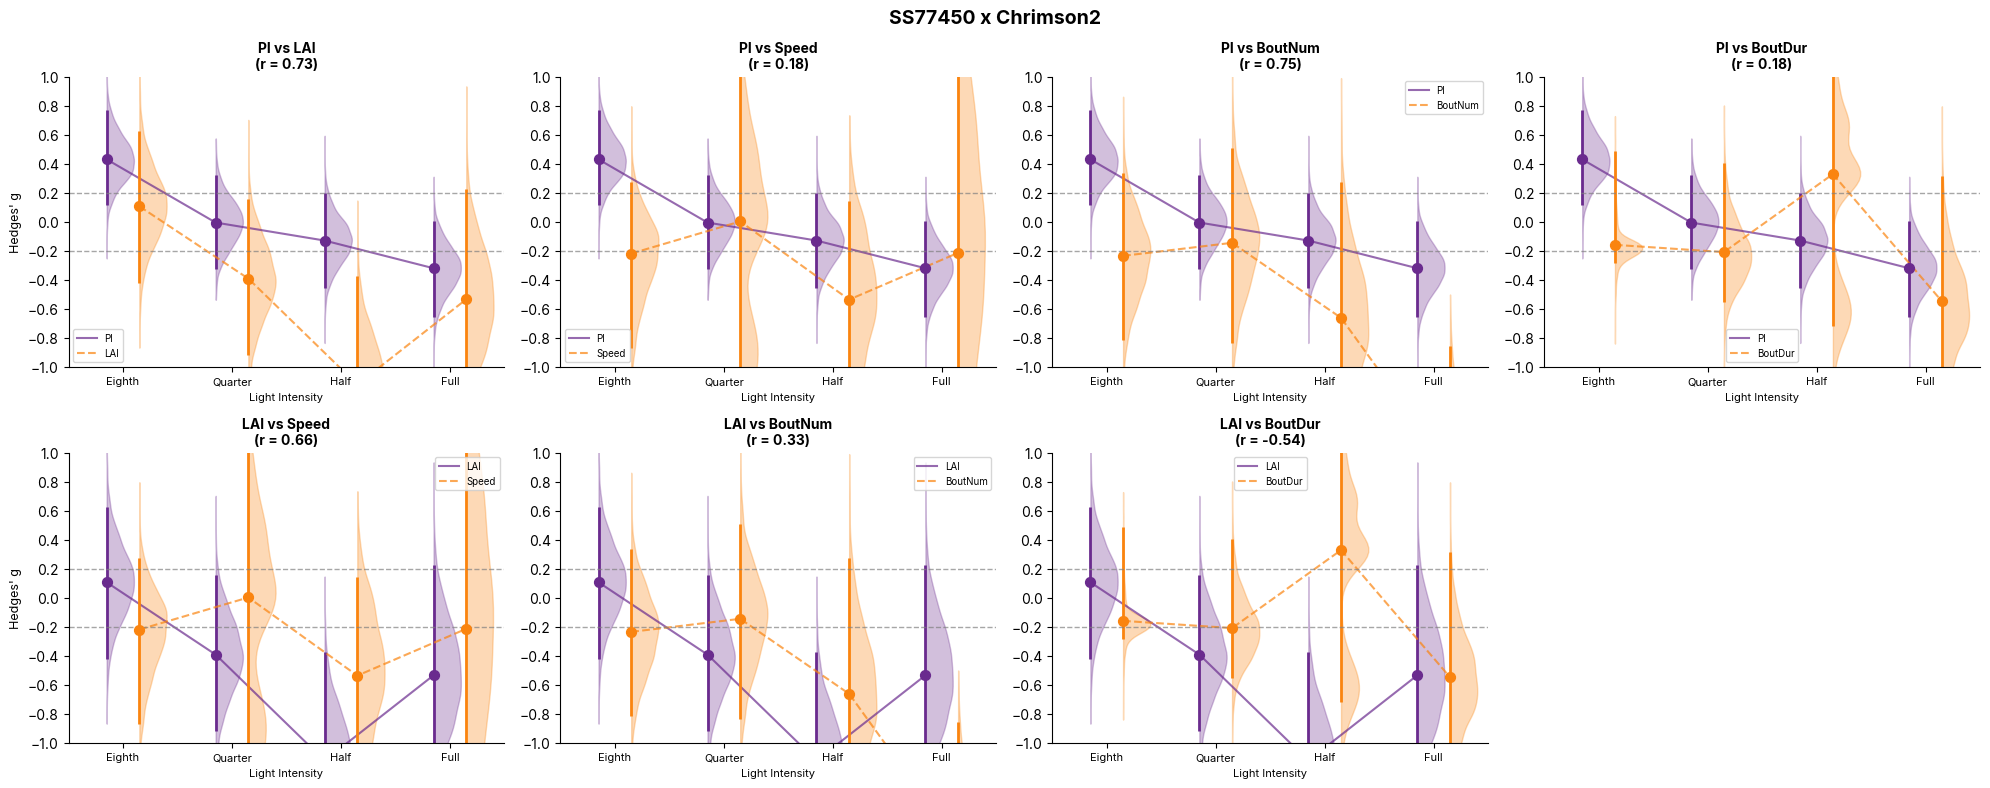

In [86]:
def plot_genotype_pairs(genotype_str):
    """Plot 2x4 grid of metric pair comparisons for a genotype."""
    mbon, responder = parse_genotype_string(genotype_str)
    pair_data = get_genotype_pair_data(osar_data, mbon, responder)

    x_pos = np.array([0, 1, 2, 3])
    intensities = ["Eighth", "Quarter", "Half", "Full"]

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    axes = axes.flatten()

    color1 = "#6A2B8E"
    color2 = "#FA840F"

    for idx, pdata in enumerate(pair_data):
        ax = axes[idx]
        metric1, metric2 = pdata["metric1"], pdata["metric2"]
        label1, label2 = pdata["label1"], pdata["label2"]
        r_val = pdata["r"]

        for metric_key, color, label in [(metric1, color1, label1), (metric2, color2, label2)]:
            for i, intensity in enumerate(intensities):
                bootstrap = get_bootstrap(osar_data, responder, intensity, metric_key, mbon)
                bootstrap = bootstrap[~np.isnan(bootstrap)]
                effect, ci_low, ci_high = get_effect(osar_data, responder, intensity, metric_key, mbon)

                if len(bootstrap) > 1 and effect is not None:
                    kde = stats.gaussian_kde(bootstrap)
                    y_kde = np.linspace(min(bootstrap), max(bootstrap), 100)
                    x_kde = kde(y_kde)
                    offset = -0.15 if metric_key == metric1 else 0.15
                    x_kde = x_kde / x_kde.max() * 0.25
                    ax.fill_betweenx(y_kde, x_pos[i] + offset, x_pos[i] + offset + x_kde, color=color, alpha=0.3)
                    ax.vlines(x_pos[i] + offset, ci_low, ci_high, color=color, linewidth=2)
                    ax.scatter(x_pos[i] + offset, effect, color=color, s=50, zorder=5)

            # Connect with line
            vals = [get_effect(osar_data, responder, intensity, metric_key, mbon)[0] for intensity in intensities]
            offset = -0.15 if metric_key == metric1 else 0.15
            linestyle = '-' if metric_key == metric1 else '--'
            if all(v is not None for v in vals):
                ax.plot(x_pos + offset, vals, linestyle, color=color, linewidth=1.5, alpha=0.7, label=label)

        ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.7, linewidth=1)
        ax.axhline(y=-0.2, color='gray', linestyle='--', alpha=0.7, linewidth=1)

        r_str = f"r = {r_val:.2f}" if r_val is not None else "omitted"
        ax.set_title(f"{label1} vs {label2}\n({r_str})", fontsize=10, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(intensities, fontsize=8)
        ax.set_yticks([-1.0, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_ylim(-1.0, 1.0)
        ax.set_xlim(-0.5, 3.5)
        ax.set_xlabel("Light Intensity", fontsize=8)
        if idx % 4 == 0:
            ax.set_ylabel("Hedges' g", fontsize=9)
        ax.legend(loc='best', fontsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Hide the 8th subplot (only 7 pairs)
    axes[7].axis('off')

    fig.suptitle(f"{mbon} x {responder}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\", f"categorical_pairs_{mbon}_{responder}.svg"), bbox_inches='tight')
    plt.show()

plot_genotype_pairs("SS77450 x Chrimson2")


## Bidirectionality

In [10]:
# Metrics for bidirectionality analysis
bidir_metrics = [
    ("PI_Hg_OSAR", "PI"),
    ("Light Attraction Index_Hg_OSAR", "LAI"),
    ("Log2 Bout Speed ratio_Hg_OSAR", "Speed"),
    ("Bout Number Index_Hg_OSAR", "BoutNum"),
    ("Bout Duration ratio_Hg_OSAR", "BoutDur"),
]

def get_all_study_mbons():
    all_mbons = set()
    for cat, states in categories.items():
        for state, mbons in states.items():
            all_mbons.update(mbons)
    return sorted(all_mbons)

def compute_bidirectionality(osar_data, mbons=None, r_threshold=0.8):
    from scipy.stats import pearsonr

    if mbons is None:
        mbons = get_all_study_mbons()

    rows = []
    for mbon in mbons:
        for metric, metric_label in bidir_metrics:
            acr_vals = get_cat_effect_values(osar_data, "ACR", metric, mbon)
            chr_vals = get_cat_effect_values(osar_data, "Chrimson2", metric, mbon)

            # Skip if data missing or both near zero
            if should_omit_pair(acr_vals, chr_vals):
                continue

            try:
                r, _ = pearsonr(acr_vals, chr_vals)
            except:
                continue

            if abs(r) >= r_threshold:
                direction = "PARALLEL" if r > 0 else "INVERSE"
                rows.append({
                    "MBON": mbon,
                    "Metric": metric,
                    "Metric_Label": metric_label,
                    "r": round(r, 2),
                    "Direction": direction,
                })

    if rows:
        return pd.DataFrame(rows)
    return pd.DataFrame()

Found 22 qualifying MBON x metric pairs:
    MBON Metric_Label     r Direction
  MB018B           PI -0.92   INVERSE
  MB018B          LAI -0.91   INVERSE
  MB077B      BoutDur -0.87   INVERSE
  MB093C        Speed -0.88   INVERSE
  MB093C      BoutDur -0.83   INVERSE
  MB210B        Speed  0.84  PARALLEL
  MB319C           PI  0.89  PARALLEL
  MB434B          LAI  0.87  PARALLEL
  MB434B      BoutNum  0.82  PARALLEL
 SS01188           PI -0.98   INVERSE
 SS01194          LAI -1.00   INVERSE
 SS01308        Speed -0.93   INVERSE
 SS01308      BoutNum  1.00  PARALLEL
 SS46348      BoutNum  0.95  PARALLEL
 SS67662      BoutDur  0.83  PARALLEL
 SS75199           PI  0.80  PARALLEL
 SS75200           PI -0.81   INVERSE
 SS77383      BoutDur  0.94  PARALLEL
 SS77442      BoutDur -0.98   INVERSE
 SS80958      BoutNum  0.85  PARALLEL
 SS81521      BoutDur  0.95  PARALLEL
VT999036      BoutNum  0.95  PARALLEL


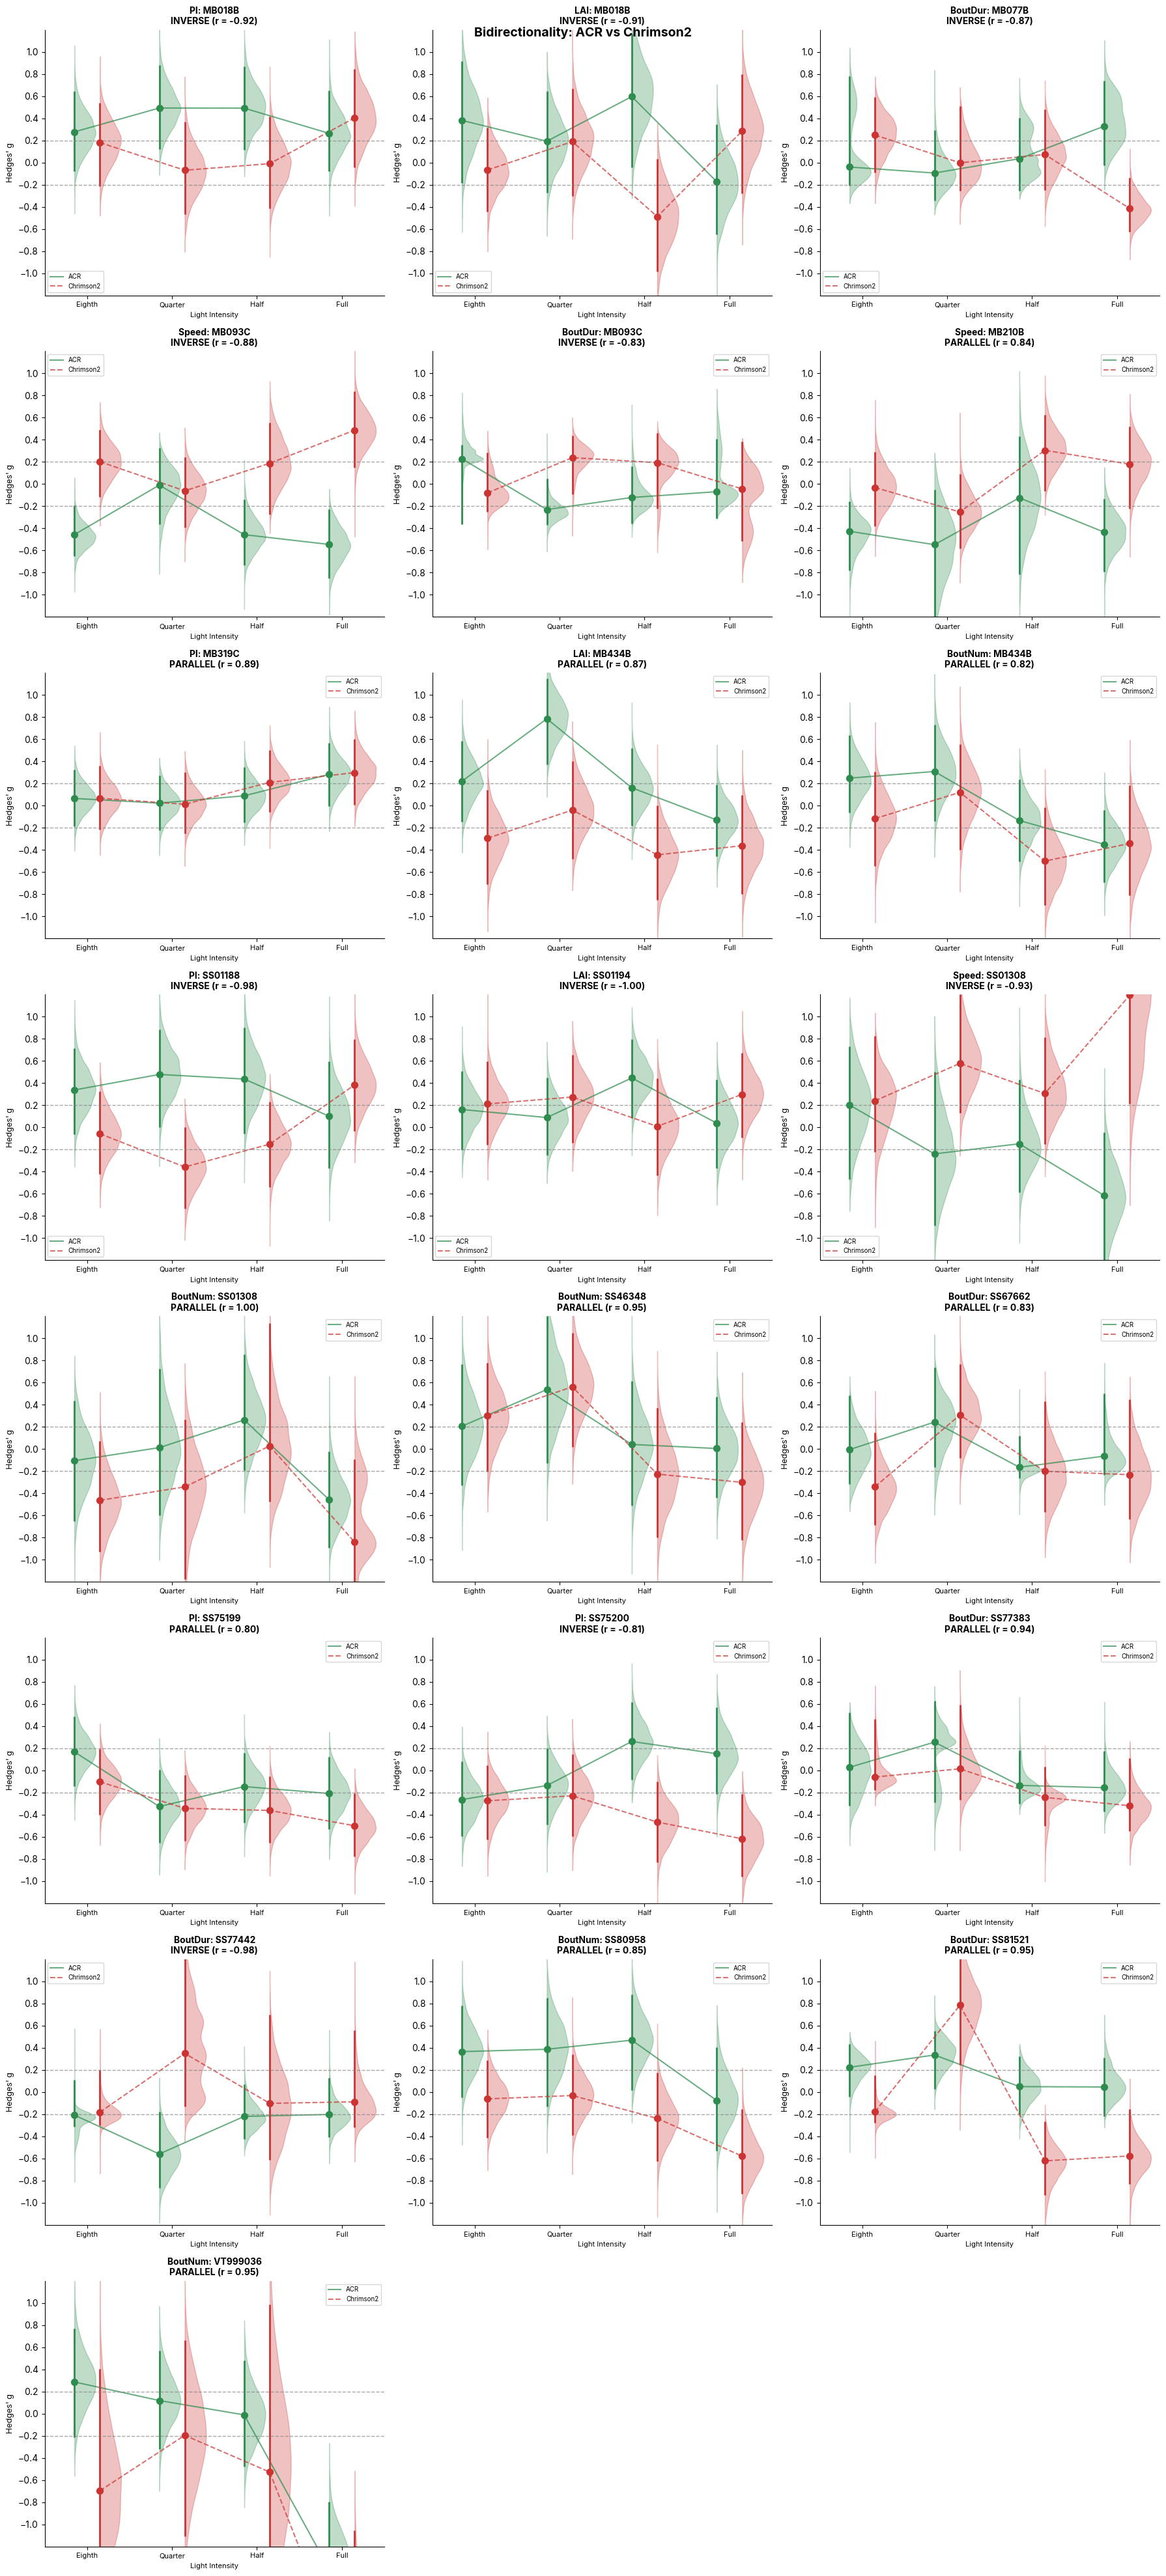

In [11]:
mpl.rcParams['svg.fonttype'] = 'none'
from scipy import stats

bidir_df = compute_bidirectionality(osar_data)

if len(bidir_df) == 0:
    print("No bidirectional pairs found with |r| >= 0.8")
else:
    print(f"Found {len(bidir_df)} qualifying MBON x metric pairs:")
    print(bidir_df[['MBON', 'Metric_Label', 'r', 'Direction']].to_string(index=False))

    # Save CSV
    bidir_df.to_csv(os.path.join("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\", "bidirectionality.csv"), index=False)

    n_plots = len(bidir_df)
    n_cols = min(3, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols

    color_acr = "#2D8C4E"
    color_chr = "#CC3333"
    x_pos = np.array([0, 1, 2, 3])
    intensities = ["Eighth", "Quarter", "Half", "Full"]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    if n_plots == 1:
        axes = np.array([axes])
    axes = np.atleast_1d(axes).flatten()

    for idx, (_, row) in enumerate(bidir_df.iterrows()):
        ax = axes[idx]
        mbon = row['MBON']
        metric = row['Metric']
        metric_label = row['Metric_Label']
        r_val = row['r']
        direction = row['Direction']

        for resp, color, linestyle in [("ACR", color_acr, '-'), ("Chrimson2", color_chr, '--')]:
            effects = []
            for i, intensity in enumerate(intensities):
                bootstrap = get_bootstrap(osar_data, resp, intensity, metric, mbon)
                bootstrap = bootstrap[~np.isnan(bootstrap)]
                effect, ci_low, ci_high = get_effect(osar_data, resp, intensity, metric, mbon)
                effects.append(effect)

                if len(bootstrap) > 1 and effect is not None:
                    kde = stats.gaussian_kde(bootstrap)
                    y_kde = np.linspace(min(bootstrap), max(bootstrap), 100)
                    x_kde = kde(y_kde)
                    offset = -0.15 if resp == "ACR" else 0.15
                    x_kde = x_kde / x_kde.max() * 0.25
                    ax.fill_betweenx(y_kde, x_pos[i] + offset, x_pos[i] + offset + x_kde, color=color, alpha=0.3)
                    ax.vlines(x_pos[i] + offset, ci_low, ci_high, color=color, linewidth=2)
                    ax.scatter(x_pos[i] + offset, effect, color=color, s=50, zorder=5)

            offset = -0.15 if resp == "ACR" else 0.15
            if all(v is not None for v in effects):
                ax.plot(x_pos + offset, effects, linestyle, color=color, linewidth=1.5, alpha=0.7, label=resp)

        ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.7, linewidth=1)
        ax.axhline(y=-0.2, color='gray', linestyle='--', alpha=0.7, linewidth=1)
        ax.set_title(f"{metric_label}: {mbon}\n{direction} (r = {r_val:.2f})", fontsize=10, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(intensities, fontsize=8)
        ax.set_yticks([-1.0, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_ylim(-1.2, 1.2)
        ax.set_xlim(-0.5, 3.5)
        ax.set_xlabel('Light Intensity', fontsize=8)
        ax.set_ylabel("Hedges' g", fontsize=9)
        ax.legend(loc='best', fontsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Hide extra subplots
    for idx in range(n_plots, len(axes)):
        axes[idx].axis('off')

    plt.suptitle("Bidirectionality: ACR vs Chrimson2", fontsize=14, fontweight='bold')
    plt.tight_layout()
    #plt.savefig(os.path.join(save_path, "bidirectionality.svg"), bbox_inches='tight')
    plt.show()

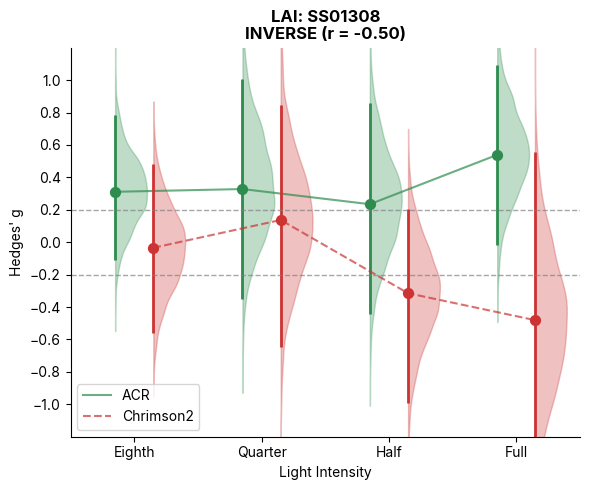

In [63]:
mbon_to_plot = "SS01308"
metric_to_plot = "Light Attraction Index_Hg_OSAR"

from scipy import stats

metric_label = dict(bidir_metrics).get(metric_to_plot, metric_to_plot)
intensities = ["Eighth", "Quarter", "Half", "Full"]
x_pos = np.array([0, 1, 2, 3])

color_acr = "#2D8C4E"
color_chr = "#CC3333"


acr_vals = get_cat_effect_values(osar_data, "ACR", metric_to_plot, mbon_to_plot)
chr_vals = get_cat_effect_values(osar_data, "Chrimson2", metric_to_plot, mbon_to_plot)

from scipy.stats import pearsonr
if all(v is not None for v in acr_vals) and all(v is not None for v in chr_vals):
    r_val, _ = pearsonr(acr_vals, chr_vals)
    direction = "PARALLEL" if r_val > 0 else "INVERSE"
else:
    r_val, direction = None, "N/A"

fig, ax = plt.subplots(figsize=(6, 5))

for resp, color, linestyle in [("ACR", color_acr, '-'), ("Chrimson2", color_chr, '--')]:
    effects = []
    for i, intensity in enumerate(intensities):
        bootstrap = get_bootstrap(osar_data, resp, intensity, metric_to_plot, mbon_to_plot)
        bootstrap = bootstrap[~np.isnan(bootstrap)]
        effect, ci_low, ci_high = get_effect(osar_data, resp, intensity, metric_to_plot, mbon_to_plot)
        effects.append(effect)

        if len(bootstrap) > 1 and effect is not None:
            kde = stats.gaussian_kde(bootstrap)
            y_kde = np.linspace(min(bootstrap), max(bootstrap), 100)
            x_kde = kde(y_kde)
            offset = -0.15 if resp == "ACR" else 0.15
            x_kde = x_kde / x_kde.max() * 0.25
            ax.fill_betweenx(y_kde, x_pos[i] + offset, x_pos[i] + offset + x_kde, color=color, alpha=0.3)
            ax.vlines(x_pos[i] + offset, ci_low, ci_high, color=color, linewidth=2)
            ax.scatter(x_pos[i] + offset, effect, color=color, s=50, zorder=5)

    offset = -0.15 if resp == "ACR" else 0.15
    if all(v is not None for v in effects):
        ax.plot(x_pos + offset, effects, linestyle, color=color, linewidth=1.5, alpha=0.7, label=resp)

ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.7, linewidth=1)
ax.axhline(y=-0.2, color='gray', linestyle='--', alpha=0.7, linewidth=1)

r_str = f"r = {r_val:.2f}" if r_val is not None else "no data"
ax.set_title(f"{metric_label}: {mbon_to_plot}\n{direction} ({r_str})", fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(intensities)
ax.set_xlim(-0.5, 3.5)
ax.set_yticks([-1.0, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel("Light Intensity")
ax.set_ylabel("Hedges' g")
ax.legend(loc='best')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
mpl.rcParams['svg.fonttype'] = 'none'
plt.tight_layout()
#plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\images\\" + mbon_to_plot + "_" + metric_to_plot + ".svg")
plt.show()

In [35]:
mbon_csv_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\MBONlist.csv"
lobelocation = pd.DataFrame()

responder = "ACR"
csvfile = pd.read_csv(mbon_csv_path).astype('string')
for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
    csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

mbons = get_sorted_mbons(osar_data, responder, METRICS[0])
for m in mbons:
    row = {'MBON': m, 'Lobe_location': find_number(csvfile, m, "Lobe"),
            'MBON_number': find_number(csvfile, m, "MBON number").strip()}
    lobelocation = pd.concat([lobelocation, pd.DataFrame([row])])
lobelocation = lobelocation.reset_index(drop=True)

def wrap_label(label, break_at=9, max_len=12):
      if len(label) > max_len:
          return label[:break_at] + "\n" + label[break_at:]
      return label

  

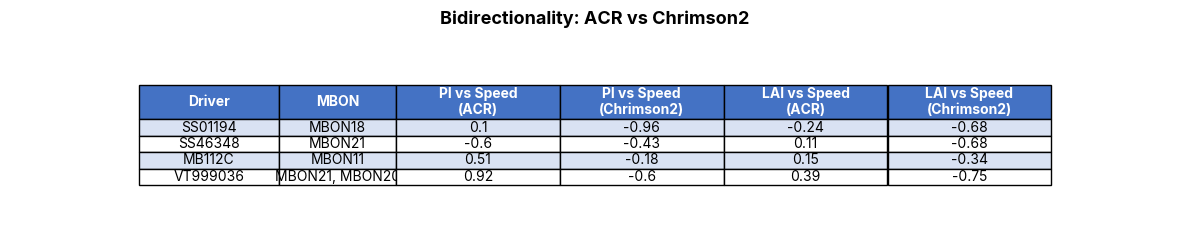

In [52]:
from scipy.stats import pearsonr

drivers = ["SS01194", "SS46348", "MB112C", "VT999036"]
metric_pairs = [
    ("PI_Hg_OSAR", "Log2 Bout Speed ratio_Hg_OSAR", "PI vs Speed"),
    ("Light Attraction Index_Hg_OSAR", "Log2 Bout Speed ratio_Hg_OSAR", "LAI vs Speed"),
]
responders = ["ACR", "Chrimson2"]

rows = []
for driver in drivers:
    info = lobelocation[lobelocation['MBON'] == driver]
    mbon_label = info['MBON_number'].values[0].strip() if len(info) > 0 else driver

    row = {"Driver": driver, "MBON": mbon_label}

    for metric_a, metric_b, pair_label in metric_pairs:
        for resp in responders:
            col_name = f"{pair_label}\n({resp})"
            vals_a = get_cat_effect_values(osar_data, resp, metric_a, driver)
            vals_b = get_cat_effect_values(osar_data, resp, metric_b, driver)

            if any(v is None for v in vals_a) or any(v is None for v in vals_b):
                row[col_name] = None
            else:
                r, _ = pearsonr(vals_a, vals_b)
                row[col_name] = round(r, 2)

    rows.append(row)

col_order = ["Driver", "MBON"]
for _, _, pair_label in metric_pairs:
    for resp in responders:
        col_order.append(f"{pair_label}\n({resp})")

bidir_table = pd.DataFrame(rows, columns=col_order)

# Render as table image
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('off')

table = ax.table(
    cellText=bidir_table.values,
    colLabels=bidir_table.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)

# Column widths
col_widths = [0.12, 0.10, 0.14, 0.14, 0.14, 0.14]
for row_idx in range(len(bidir_table) + 1):
    for col_idx, w in enumerate(col_widths):
        table[row_idx, col_idx].set_width(w)

# Header height (taller for wrapped labels)
for col_idx in range(len(bidir_table.columns)):
    table[0, col_idx].set_height(0.18)

# Style header row
for col_idx in range(len(bidir_table.columns)):
    cell = table[0, col_idx]
    cell.set_facecolor('#4472C4')
    cell.set_text_props(color='white', fontweight='bold')

# Alternate row shading
for row_idx in range(1, len(bidir_table) + 1):
    color = '#D9E2F3' if row_idx % 2 == 1 else 'white'
    for col_idx in range(len(bidir_table.columns)):
        table[row_idx, col_idx].set_facecolor(color)

plt.title("Bidirectionality: ACR vs Chrimson2", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
#plt.savefig(os.path.join(save_path, "bidirectionality_table.svg"), bbox_inches='tight')
plt.show()